In [1]:
#system
import os
import sys
sys.path.insert(0, "/home/thomasb/")
#general
import numpy as np 
import numba as nb
import time
import importlib
import json
import argparse
import h5py
from matplotlib import pyplot as plt
from datetime import datetime as dt
#utils
from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils
from albatros_analysis.src.utils import finetiming_utils as futils
#helpers and functions
from scipy.optimize import minimize,check_grad,least_squares
from scipy.ndimage import median_filter
from scipy.ndimage import binary_opening, binary_closing, label
from skyfield.api import load, wgs84
#etc

sys.path.append(os.path.expanduser('~'))

BDC is using numpy
BDC is using numpy


In [2]:
#PLOT STYLE
plt.style.use('seaborn-v0_8-ticks')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300
})

In [5]:
path_config = "/home/thomasb/albatros_analysis/scripts/orbcomm/config/config_batch2.json"

with open(path_config, "r") as f:
    config = json.load(f)
antpos=[]
for i, (ant, details) in enumerate(config["antennas"].items()):
    antpos.append(details["coordinates"])
print(antpos)

batch_start_ts = config["correlation"]["start_timestamp"]
batch_end_ts = config["correlation"]["end_timestamp"]
osamp = config['correlation']['osamp']
acclen = config['correlation']['new_acclen']

acclen = 512
acclen2 = 1024

T_SPECTRA = 4096/250e6 * osamp
print(T_SPECTRA)

[[79.41716147, -90.76723869, 187.9577], [79.41719805, -90.75873919, 183.0684], [79.38845641, -91.01920296, 25.1938], [79.41830257, -90.66739545, 59.6242], [79.39798424, -90.79984241, 41.699], [79.41147412, -90.69526613, 31.6314], [79.44375769, -90.71820263, 414.9131]]
0.001048576


In [43]:
path_batch = f'/scratch/thomasb/batch_{batch_start_ts}'

path_pulses = os.path.join(path_batch, "data/pulses.json")
with open(path_pulses, "r") as f:
        pulse_list = json.load(f)

path_cutter_discrep = os.path.join(path_batch, "data/cutting_discrep.json")
with open(path_cutter_discrep, "r") as f:
        dict_cutter_discrep = json.load(f)

path_map = os.path.join(path_batch, 'timing_discrepancies/times_all.json')
with open(path_map, "r") as f:
        map_dict = json.load(f)

In [44]:
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
ant_idxs = [0, 1, 2, 3, 4, 5, 6]
nant_used = len(ant_idxs)
n_blines = len(ant_idxs)*(len(ant_idxs)-1)//2

In [45]:
idx_pulse = 2

#extract from pulses json
pulse = pulse_list[idx_pulse]
print(pulse)

pulse_start_ts = pulse['t_start']
pulse_end_ts = pulse['t_end']
satID = pulse['sat']
chan_det = pulse['channel']
print('detection channel', chan_det)

pulse_start_spec = pulse['start_specnum']
#pulse_start_spec = 645383886 - 70656*osamp
print(pulse_start_spec)

assert satID in {59051, 57166, 28654,25338,33591}
if satID in {59051, 57166}:
    masking = False
if satID in {28654,25338,33591}:
    masking=True

print('masking:', masking)
if chan_det%2 == 0:
    chans_old = np.arange(chan_det-2, chan_det+2) + 1834
else:
    chans_old = np.arange(chan_det-1, chan_det+3) + 1834

print(chans_old)

{'antenna': 'Antenna 2', 'sat': 57166, 'channel': 3, 't_start': 1753204614, 't_end': 1753204909, 'len': 295, 'start_specnum': 273770916}
detection channel 3
273770916
masking: False
[1836 1837 1838 1839]


In [46]:
fname_data = f"data_raw_osamp=64_start={pulse_start_ts}_end={pulse_end_ts}_chans={chans_old[0]}:{chans_old[-1]}.npy"

#extract from discrep cutter (to get channels)
cut_discrep = dict_cutter_discrep[fname_data]

chan_new_start, chan_new_end  = cut_discrep["cut_chans"]
chans_new = np.arange(chan_new_start, chan_new_end)
nchans = len(chans_new)
print(nchans)
print(chans_new)

freqs = (chans_new/64 + chans_old[0])*250e6/4096
freqs = 250e6-freqs
freqs_normalized = freqs/1e9

data1 = np.load(os.path.join(path_batch, 'data', fname_data))
data1 = data1[:, :, :, chans_new]
nant = data1.shape[0]
print(data1.shape)
print(nant)

80
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80]


(7, 2, 280576, 80)
7


In [47]:
UTC_per_spec = map_dict['fit']['UTC_per_spec']
UTC_offset = map_dict['fit']['UTC_offset']
# UTC_per_spec = 1.638400946109685e-05
# UTC_offset = 1753200128.469018

pstart1 = UTC_per_spec*pulse_start_spec + UTC_offset
print(pstart1)

tle_path = outils.get_tle_file(pstart1, "/project/rrg-sievers/mohanagr/OCOMM_TLES")

1753204613.884398


In [48]:
#using newly computed stuff
print(data1.shape)

(7, 2, 280576, 80)


In [ ]:
importlib.reload(futils)
vis1 = futils.get_vis(data1,satID,freqs,pstart1,pulse_end_ts,antpos,ant_idxs,tle_path,T_SPECTRA,acclen)

vis shape (21, 548, 80)
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.21682524681091309


done 0 1 .Processed 1 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.23691391944885254
done 0 2 .Processed 2 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.15674567222595215
done 0 3 .Processed 3 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.2543766498565674
done 0 4 .Processed 4 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.24235796928405762
done 0 5 .Processed 5 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.2053060531616211
done 0 6 .Processed 6 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.2277512550354004
done 1 2 .Processed 7 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.18111872673034668
done 1 3 .Processed 8 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.19678354263305664
done 1 4 .Processed 9 baselines
catalog #57166 epoc

In [ ]:
#make adaptive. while loop maybe? needs a minimum number of real points.
if masking:
    mask1 = futils.get_mask(vis1, tol=1.8)
else:
    mask1 = None

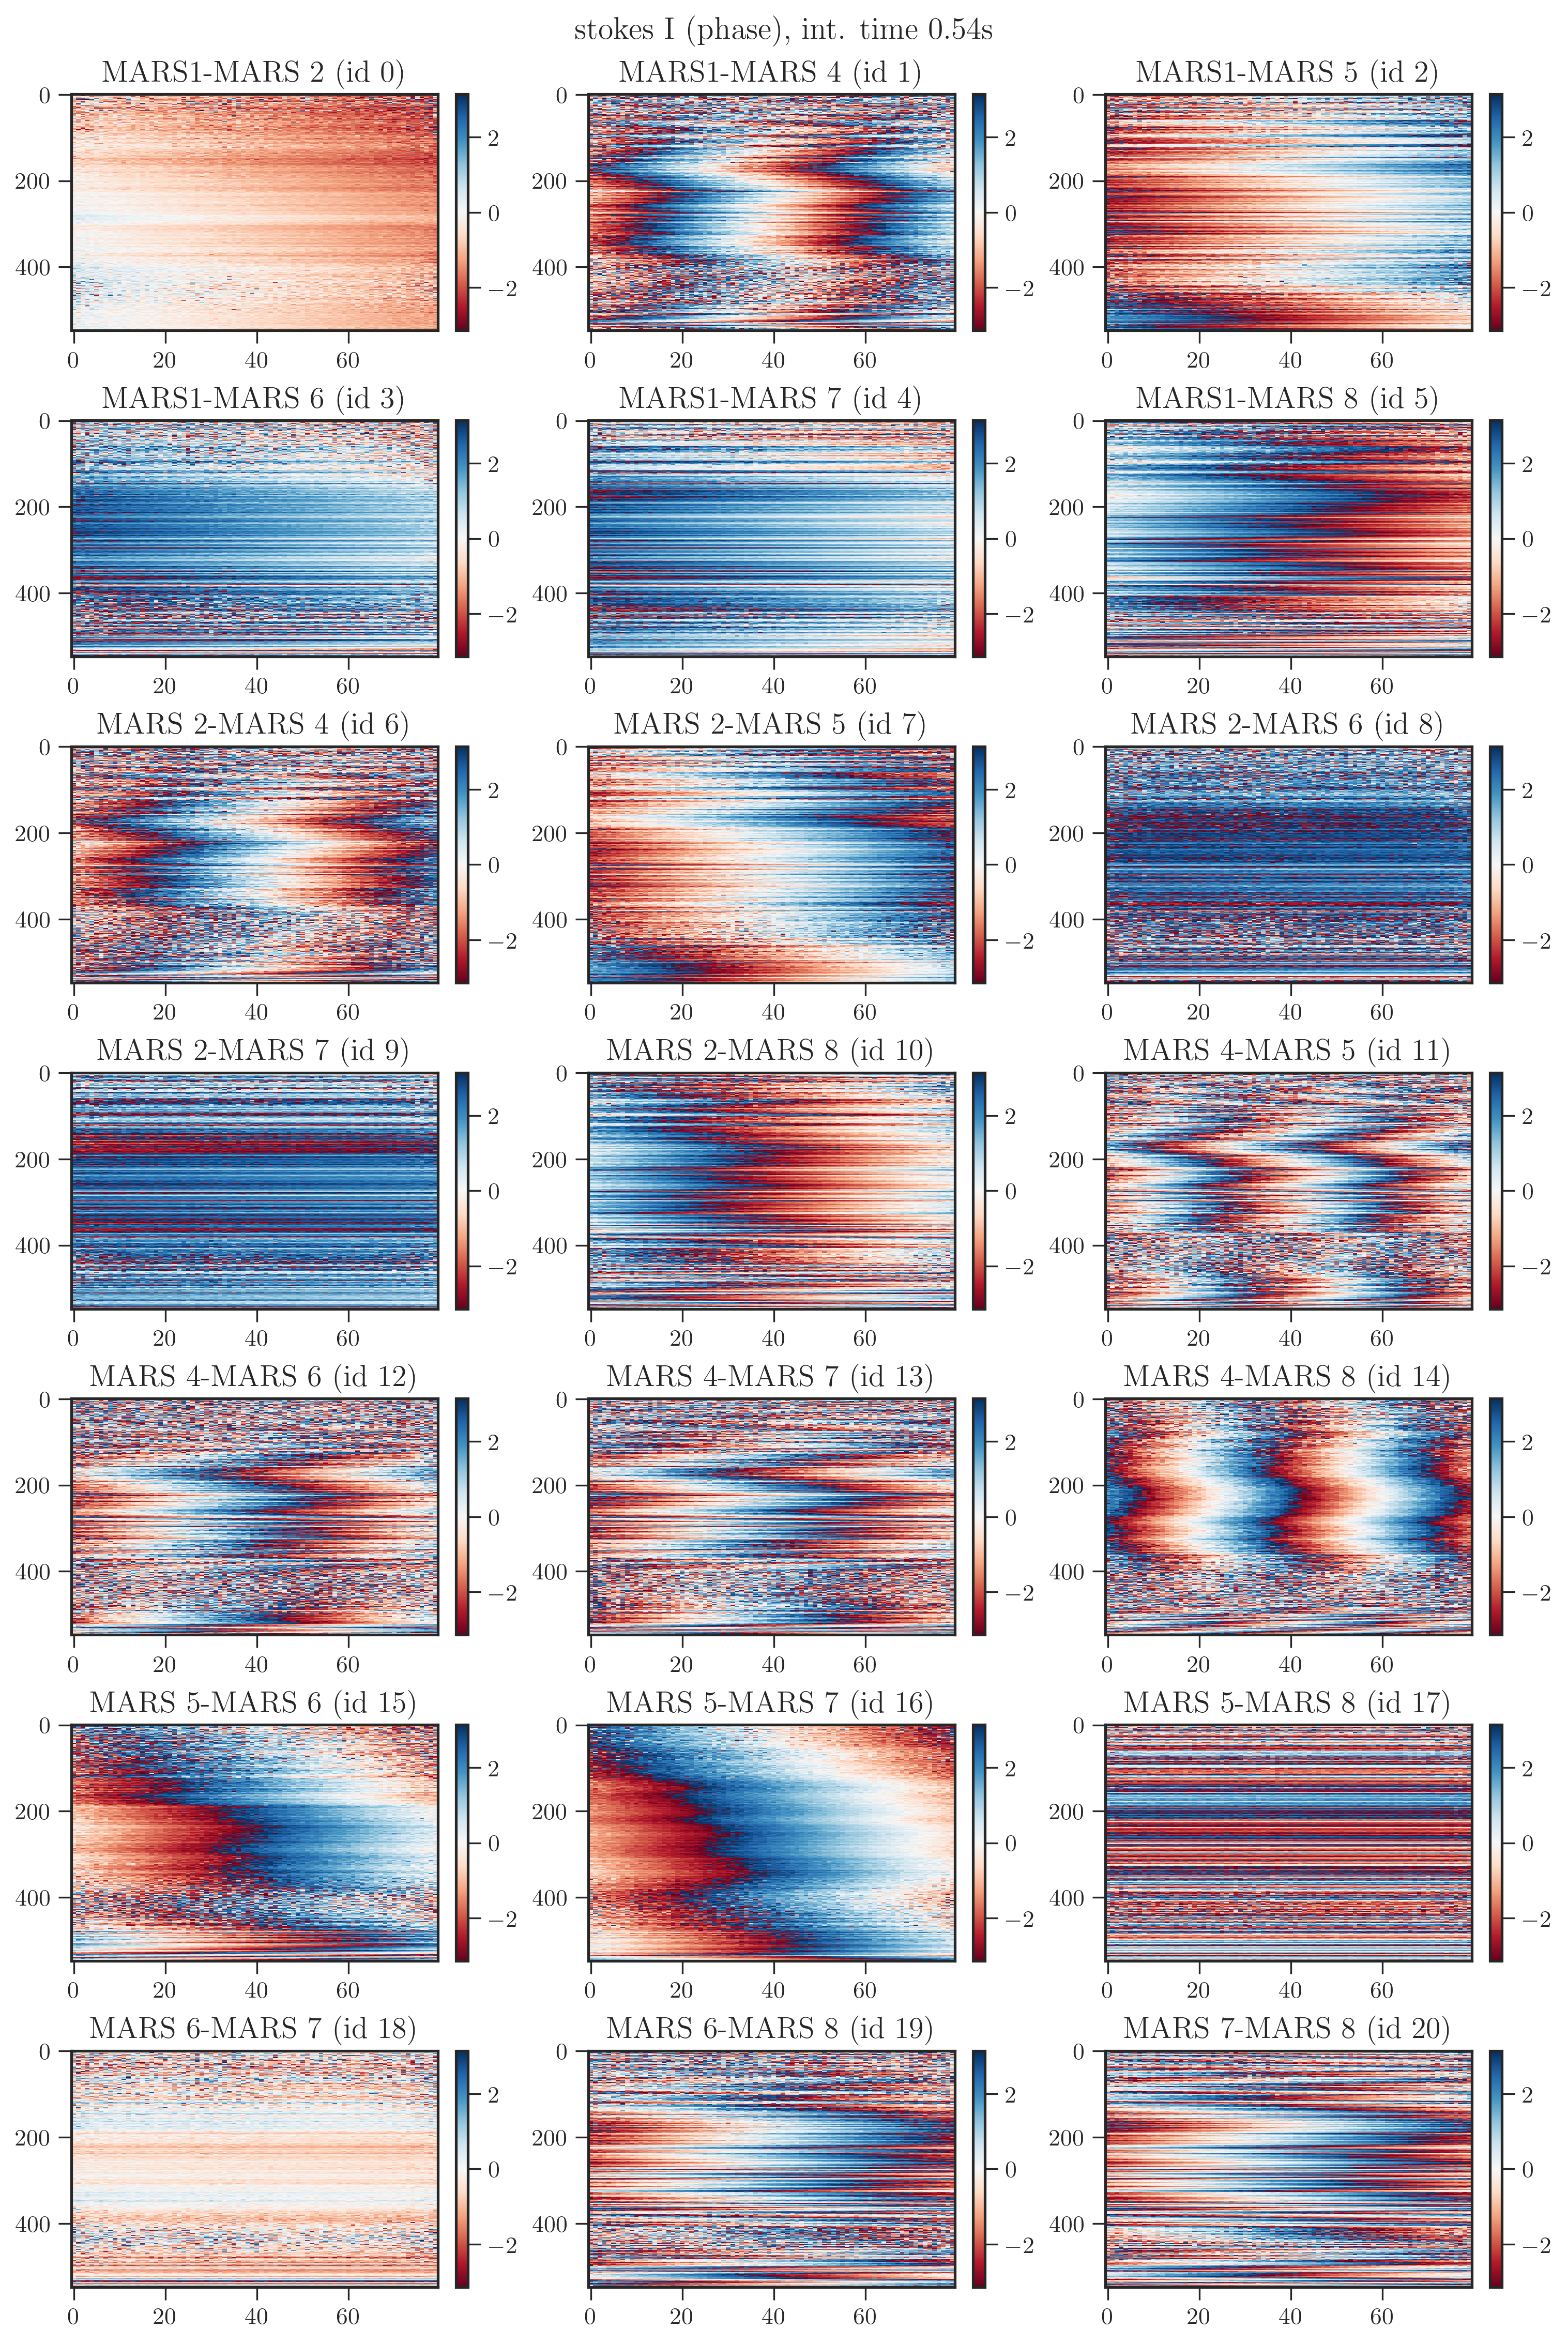

In [ ]:
importlib.reload(futils)  
thermal_noise1, fig = futils.get_thermal_noise(vis1, ant_idxs, mask=mask1, T_SPECTRA = T_SPECTRA, acclen=acclen)

(21, 548)


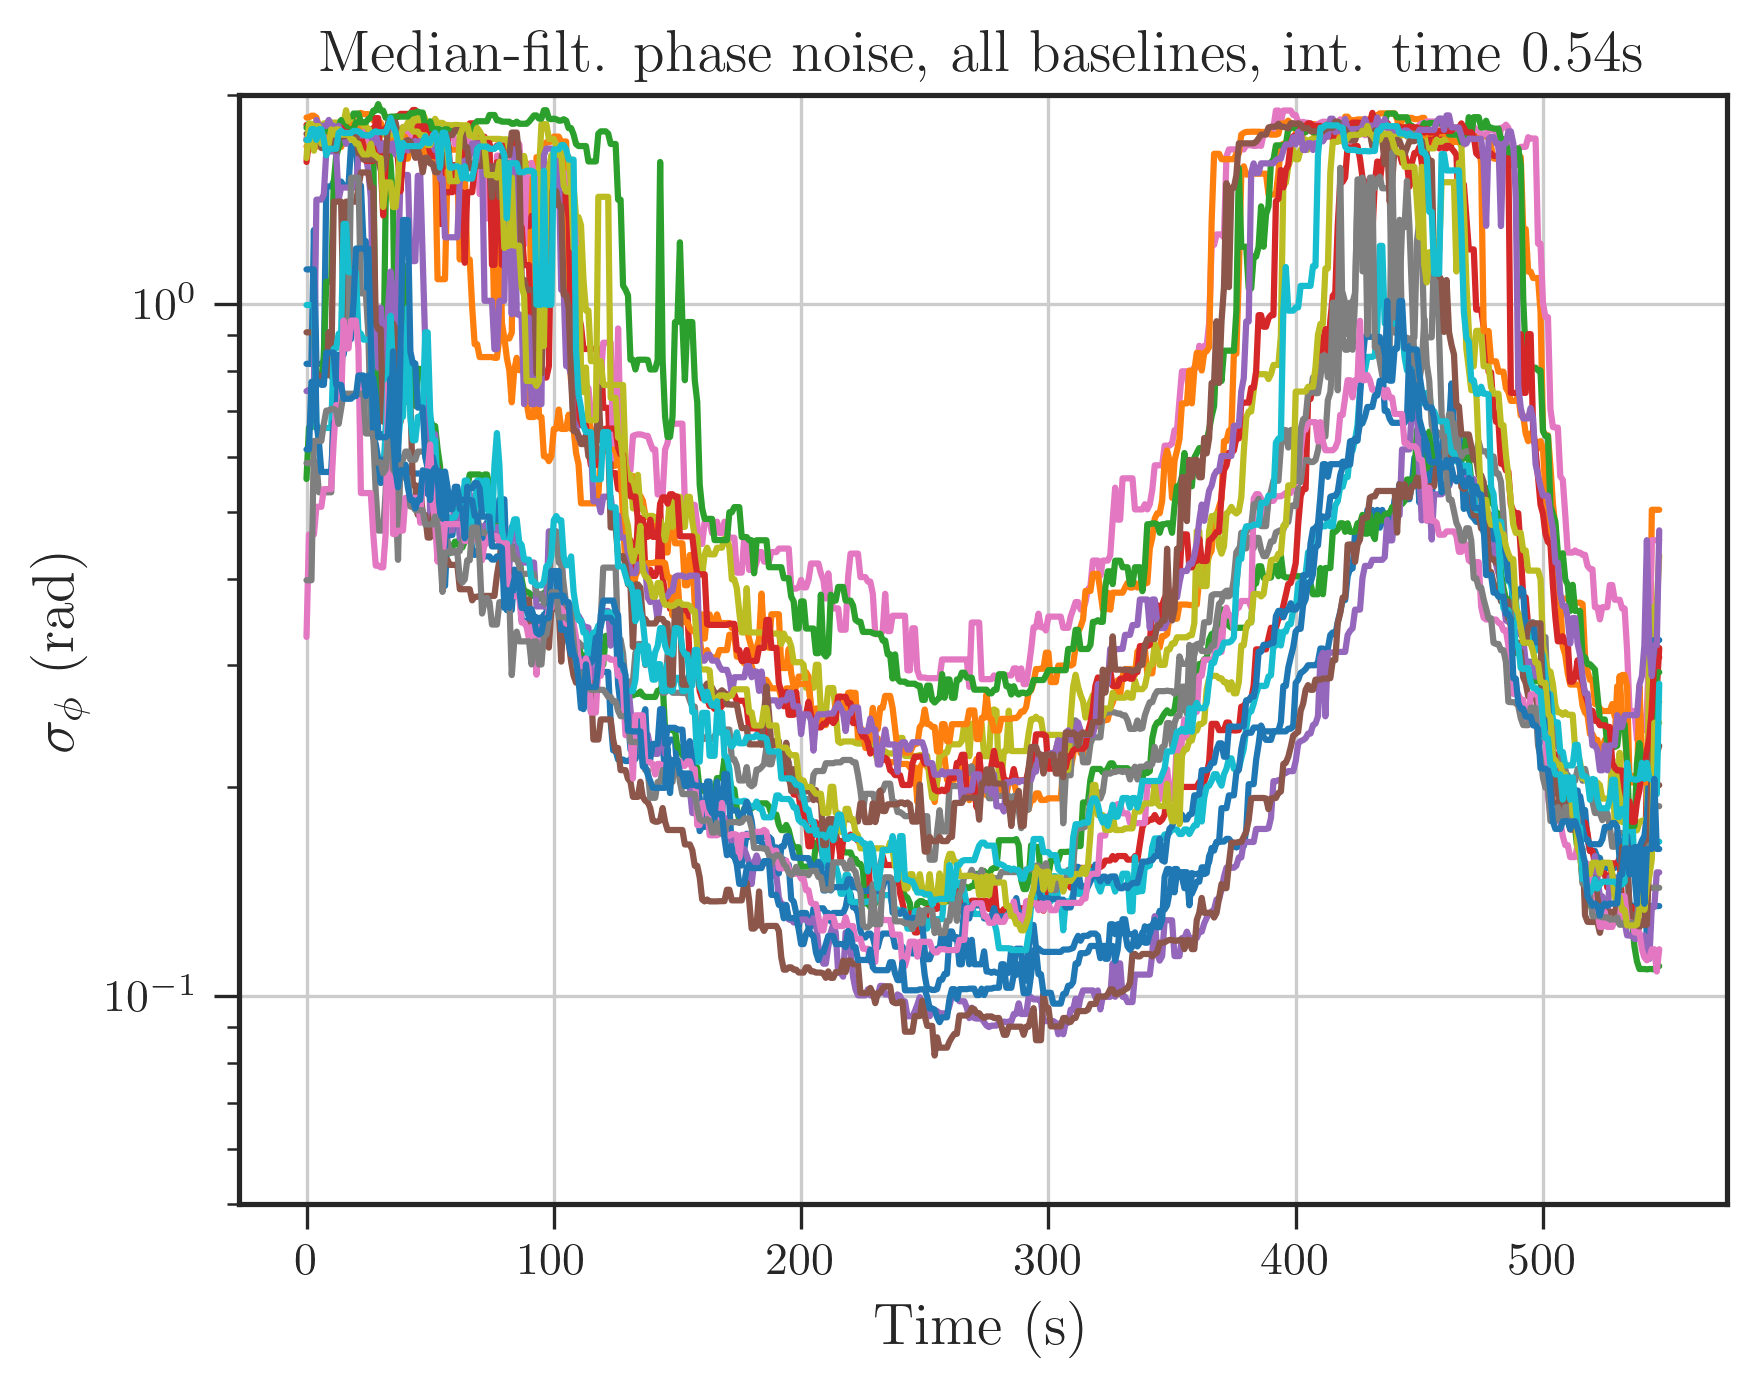

In [52]:
print(thermal_noise1.shape)
for bl in range(n_blines):
    plt.semilogy(median_filter(thermal_noise1[bl,:],10),label=f'bl id {bl}')
plt.title(f"Median-filt. phase noise, all baselines, int. time {T_SPECTRA*acclen:4.2f}s")
plt.ylabel("$\sigma_\phi$ (rad)")
plt.xlabel("Time (s)")
plt.ylim(0.05,2)
plt.grid(True)

In [ ]:
start_cut, end_cut = futils.find_lowest_noise(thermal_noise1, window_size = 240)


#start_cut, end_cut = 10, 130

print(start_cut, end_cut)
start_spectra, end_spectra = start_cut*acclen, end_cut*acclen

140 380


In [54]:
pulse_start_spec_cut = pulse_start_spec+start_spectra*64
pstart2 = UTC_per_spec*pulse_start_spec_cut + UTC_offset
print(pstart2)

data2 = data1[:,:,start_spectra:end_spectra,:]
print(data2.shape)

1753204689.0464544
(7, 2, 122880, 80)


In [ ]:
vis2 = futils.get_vis(data2,satID,freqs,pstart2,pulse_end_ts,antpos,ant_idxs,tle_path,T_SPECTRA,acclen)
nblines, ntimes, nchans = vis2.shape
print(vis2.shape)

vis shape (21, 240, 80)
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.12172985076904297
done 0 1 .Processed 1 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.1374502182006836
done 0 2 .Processed 2 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.16099309921264648
done 0 3 .Processed 3 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.11672806739807129
done 0 4 .Processed 4 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.15973997116088867
done 0 5 .Processed 5 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.11711478233337402
done 0 6 .Processed 6 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.11815786361694336
done 1 2 .Processed 7 baselines
catalog #57166 epoch 2025-07-22 18:35:47 UTC
one delay prediction: 0.15715694427490234
done 1 3 .Processed 8 baselines
catalog #57166 epoch 2025

In [ ]:
masking=False
if masking:
    mask2 = futils.get_mask(vis2, tol=1.7)
else:
    mask2 = None

In [24]:
#(optional) load in the simulation!!
#d = np.load('/scratch/thomasb/sim_finetiming/osamp1vis.npz')
d = np.load('/scratch/thomasb/sim_finetiming/osampvis_v2.npz')

vis2 = d['vis'][np.newaxis,:,:]
chans = d['chans'][:]
print(chans.shape)
print(vis2.shape)

nchans = 120
nant = 2
nblines = 1
#ntimes = 183
ant_idxs = [0,1]
nant_used = 2
T_SPECTRA = 4096/250e6
acclen = 1024
osamp = 64

freqs = (chans/64) * 250e6/4096
#freqs = 250e6-freqs
freqs_normalized = freqs/1e9
print(freqs[0])

(3840,)
(1, 183, 3840)
111694335.9375


In [ ]:
#for single window
#chan_start = 70
#chan_end = 170

# for many window
s1, e1 = 938, 962
s2, e2 = 1593, 1617
s3, e3 = 2222, 2246
s4, e4 = 2877, 2901
s5, e5 = 3507, 3531

windows = [(s1, e1),(s2, e2),(s3, e3),(s4, e4),(s5, e5)]

freqs = np.concatenate([freqs[s:e] for s, e in windows])
print(freqs.shape)
freqs_normalized = freqs/1e9

vis2 = np.concatenate([vis2[:, :, s:e] for s, e in windows], axis = 2)
print(vis2.shape)

(120,)
(1, 183, 120)


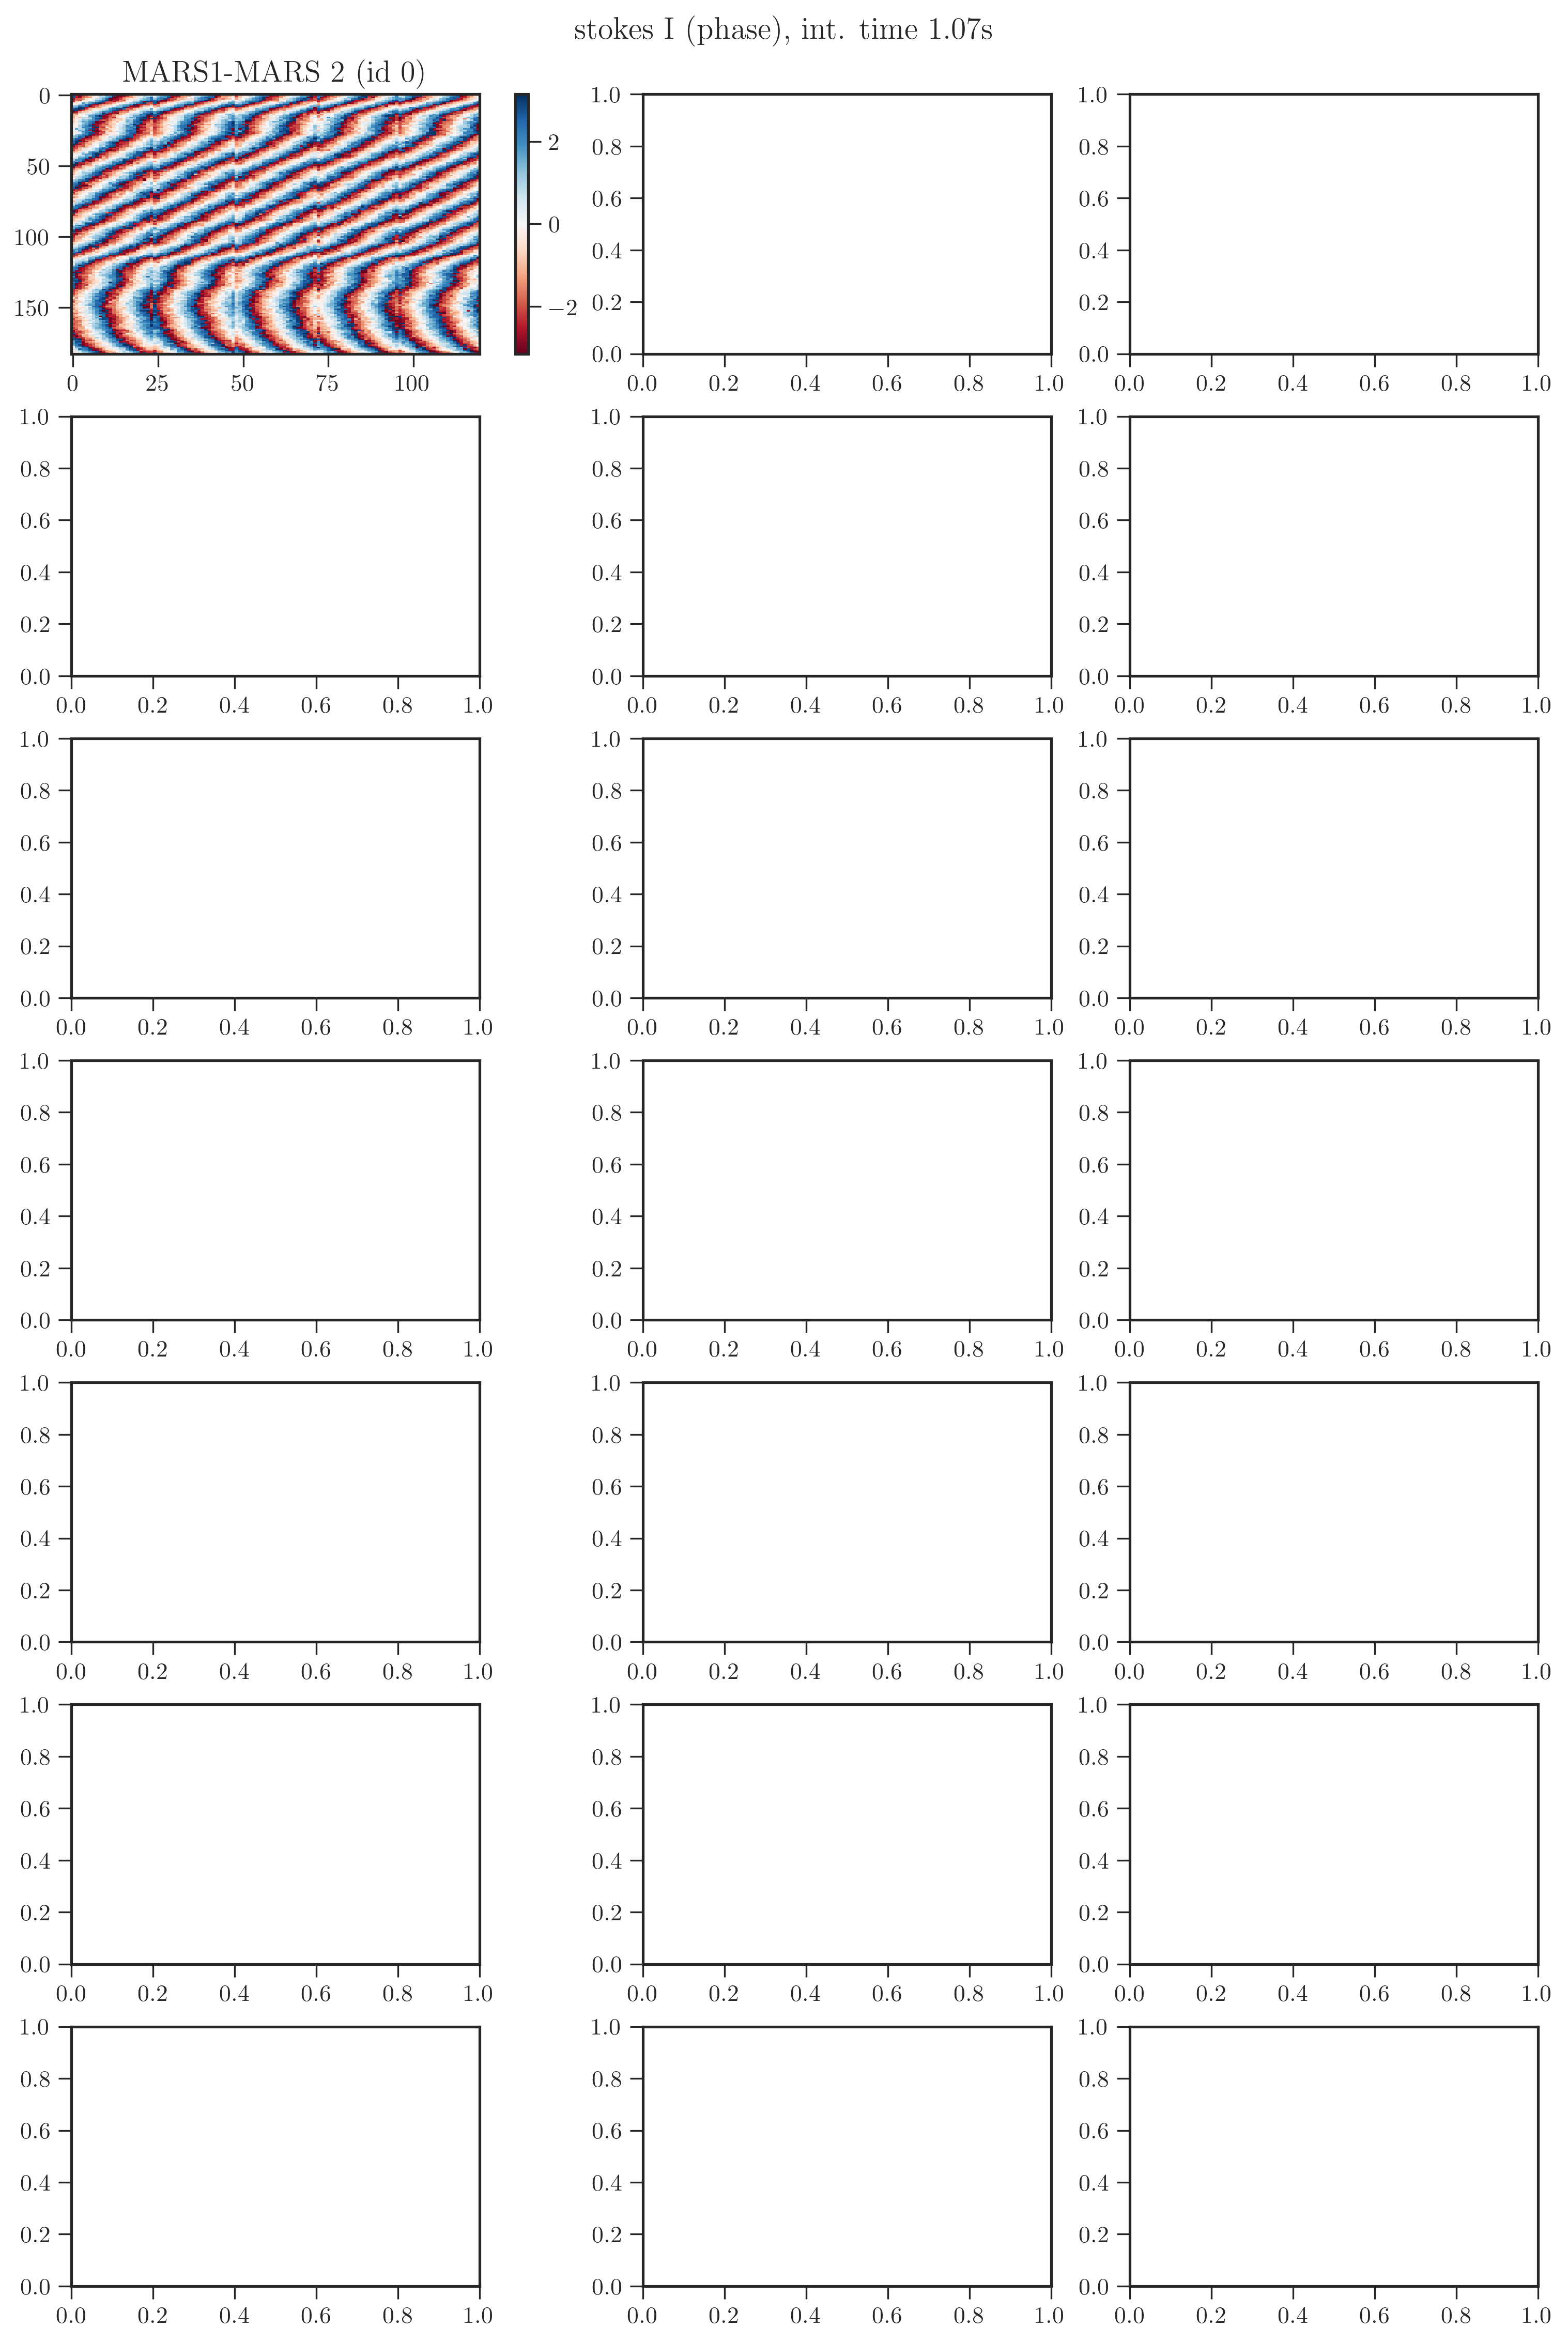

In [26]:
#plot fully cut pulse, get thermal noise
thermal_noise2, _ = futils.get_thermal_noise(vis2, ant_idxs, mask=mask2, acclen = acclen)

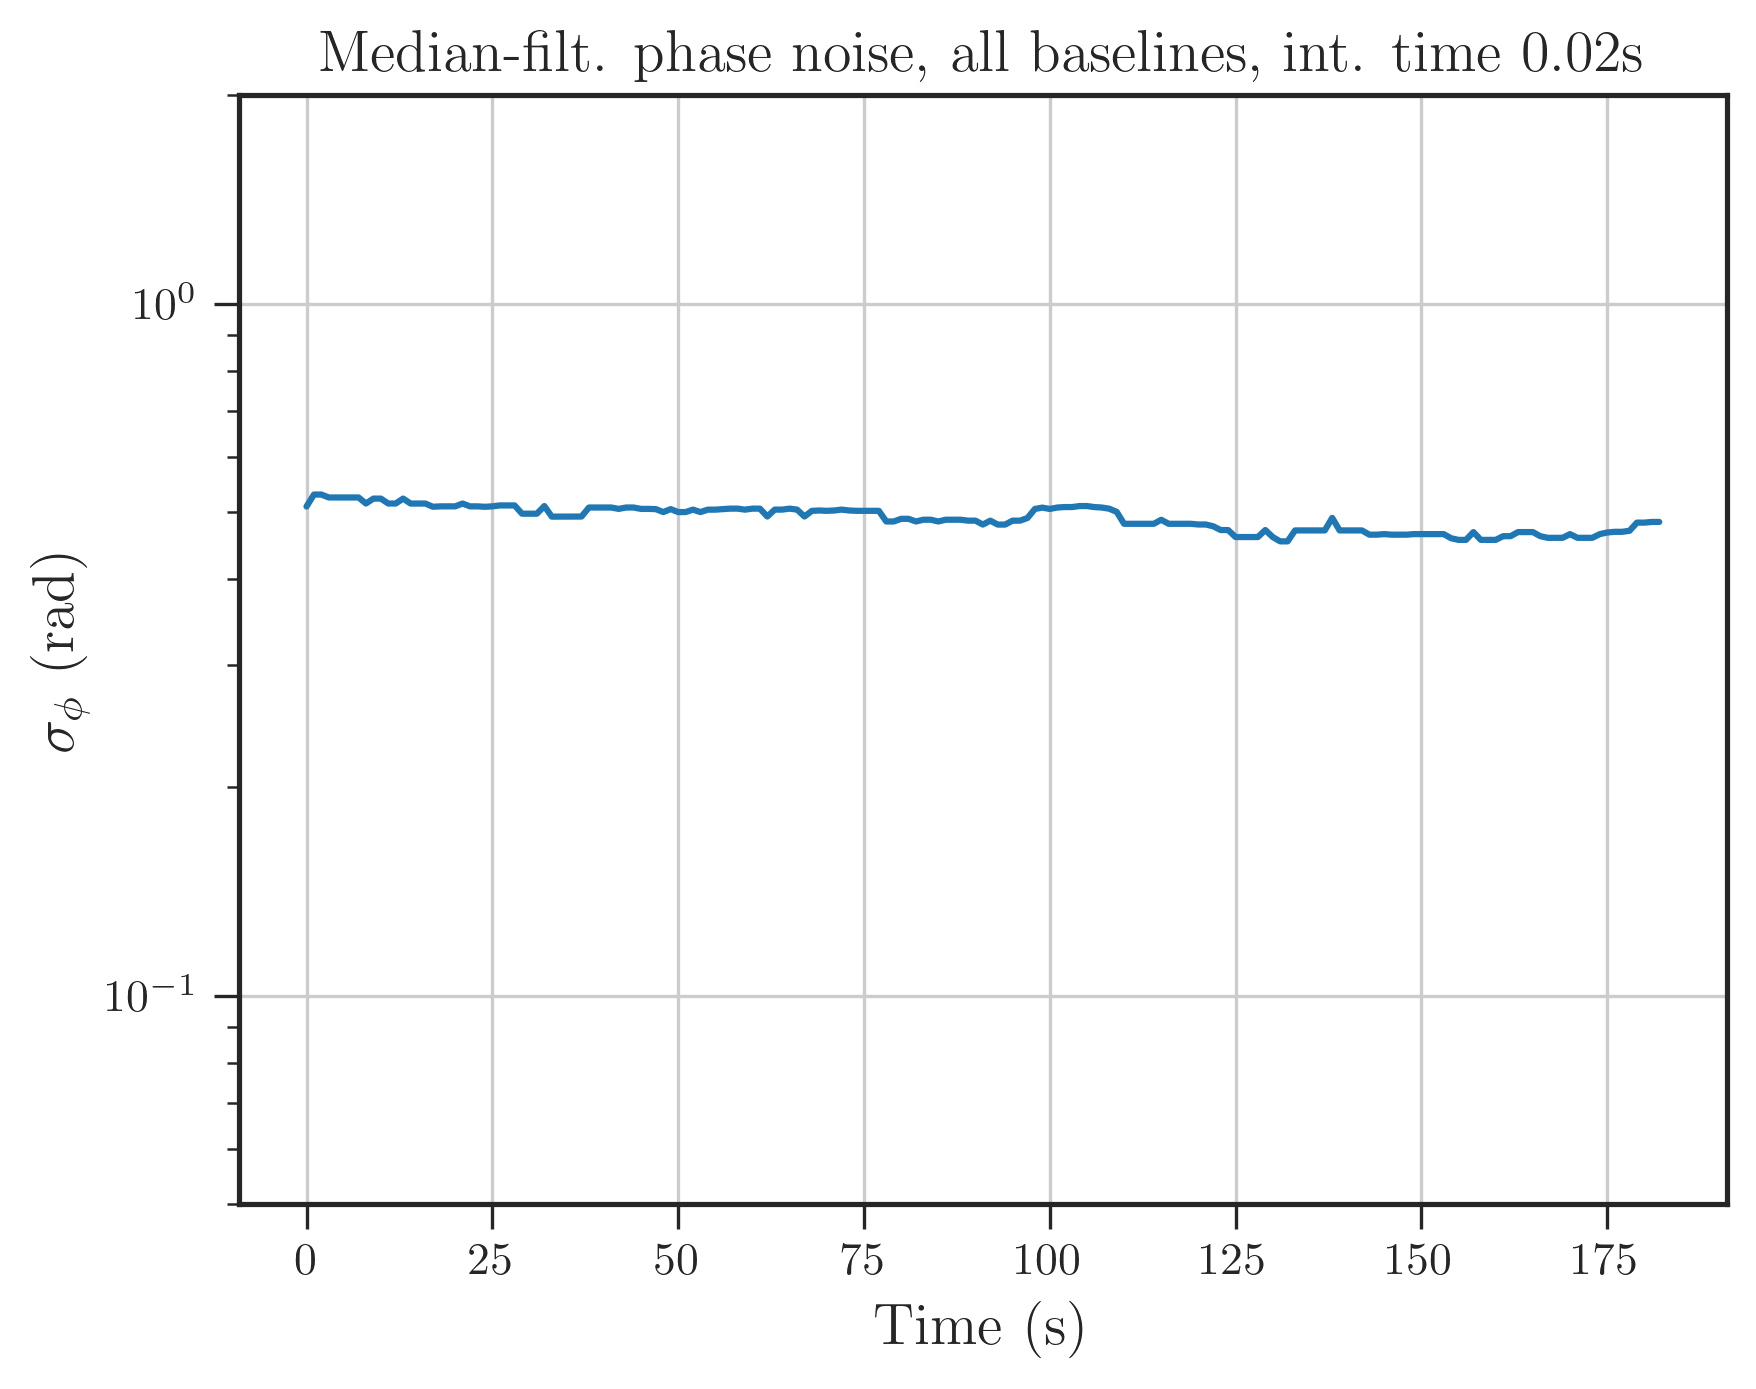

In [27]:
#plot the thermal noise (smoothed a bit)
for bl in range(nblines):
    plt.semilogy(median_filter(thermal_noise2[bl,:],10),label=f'bl id {bl}')
plt.title(f"Median-filt. phase noise, all baselines, int. time {T_SPECTRA*acclen:4.2f}s")
plt.ylabel("$\sigma_\phi$ (rad)")
plt.xlabel("Time (s)")
plt.ylim(0.05,2)
plt.grid(True)

(1, 120)
(1, 120)


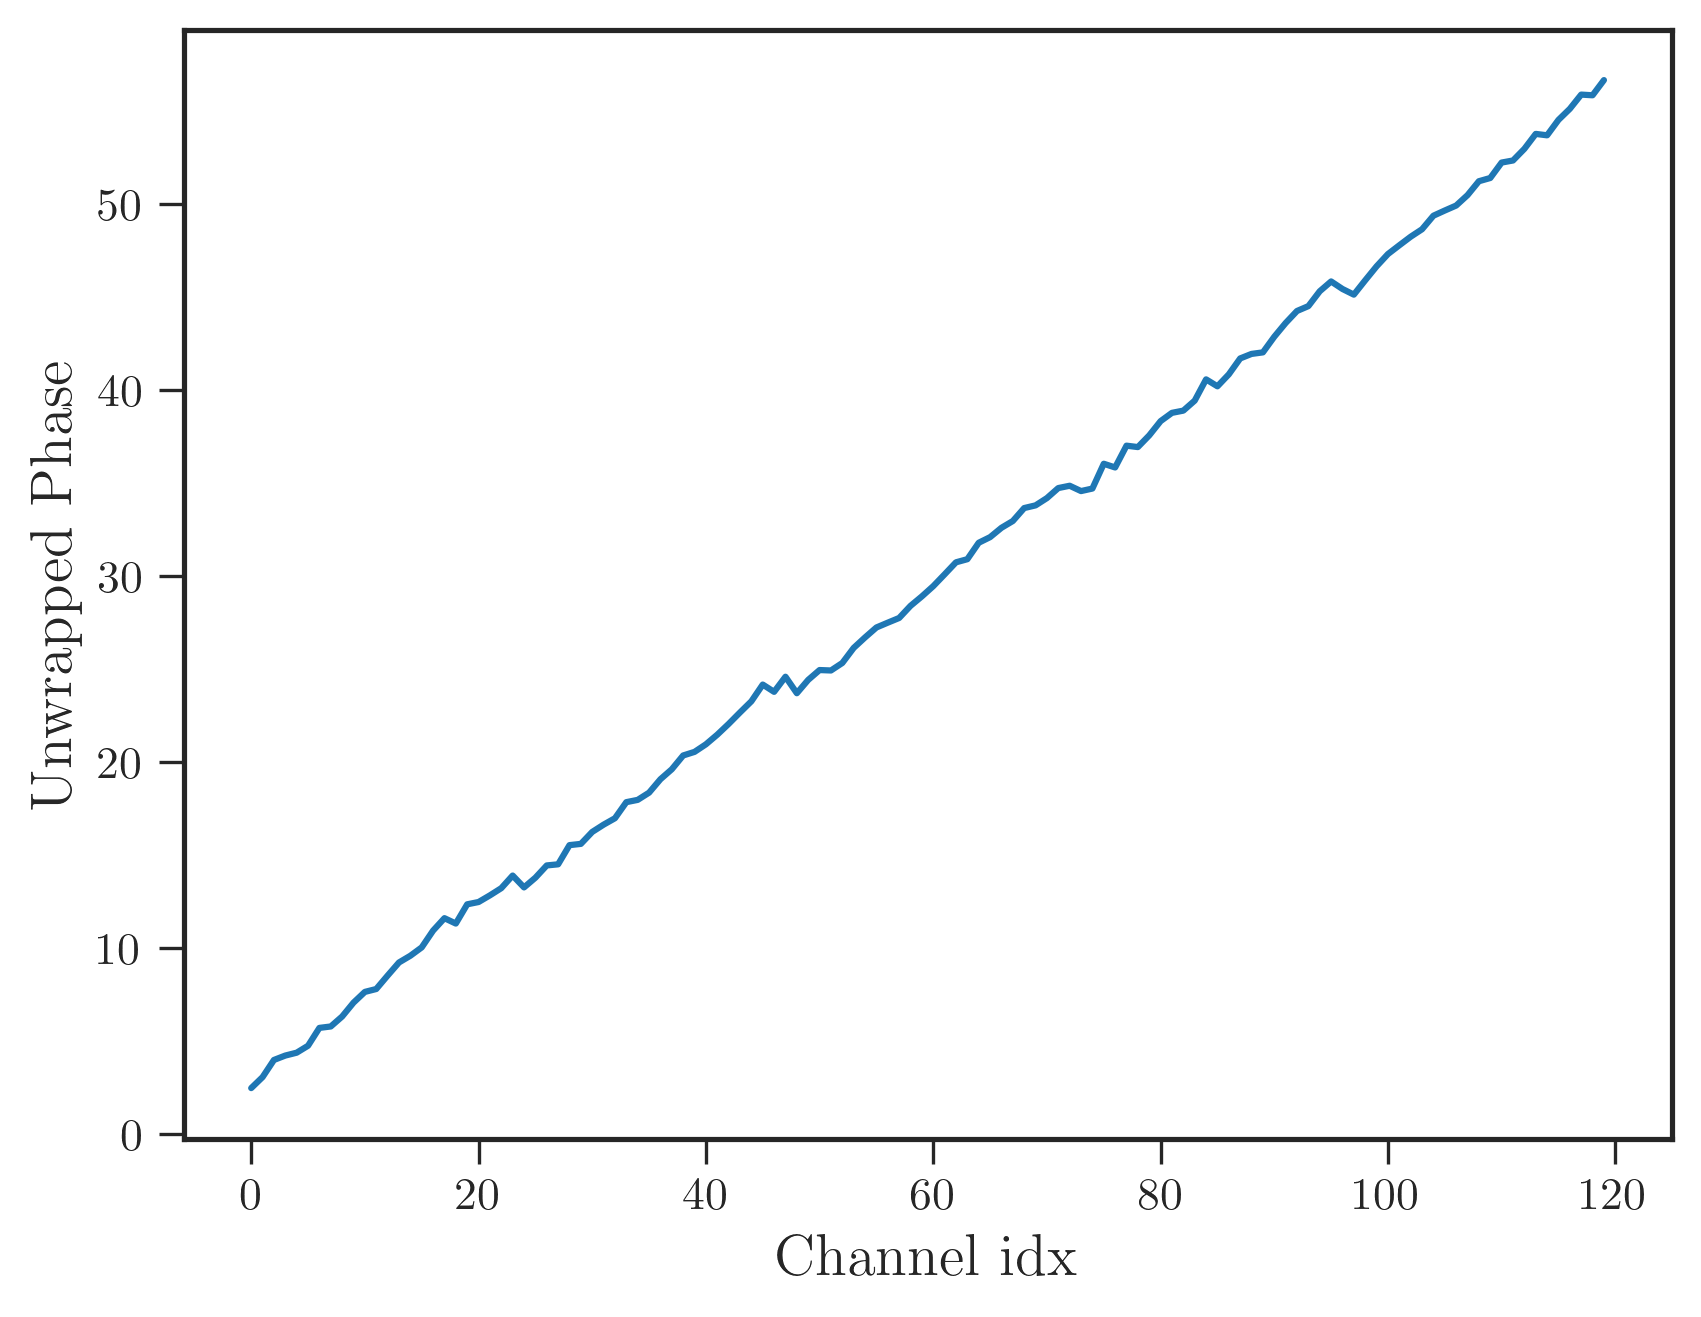

In [32]:
#get an initial guess for tau
avg_multi_vis = np.mean(vis2[:, 80:82, :], axis=1)
nbl = avg_multi_vis.shape[0]
print(avg_multi_vis.shape)

avg_multi_phase = np.unwrap(np.angle(avg_multi_vis), axis = 1)
#avg_multi_phase = avg_multi_phase - avg_multi_phase[:, 39][:, None]
for i in range(nbl):
    plt.plot(avg_multi_phase[i,:])
plt.xlabel('Channel idx')
plt.ylabel('Unwrapped Phase')

#get that noise by fitting a line and getting std of residuals
noise_matrix_avg = np.zeros((1,nbl),dtype='float64')
x = freqs
for bl in range(nbl):
    y = avg_multi_phase[bl,:]
    m, c = np.polyfit(x,y, 1)
    residual = y - (m*x + c)
    noise_matrix_avg[0,bl] = np.std(residual)
# print(noise_matrix_avg)
print(avg_multi_phase.shape)

In [ ]:
#fit onto the guess ramp using normal equations
#============
#non-sim
data_matrix = avg_multi_phase.T.reshape(1,nchans,nbl)
#sim
#data_matrix = avg_multi_phase.reshape(1, 100, 1)
#============

print(data_matrix.shape)
Ag = futils.get_grammian(nant)
AtA2,Atd2 = futils.get_AtA_Atd(data_matrix,
                        Ag,
                        noise_matrix_avg**2,
                        freqs_normalized,
                        nant,
                        nchans,  
                        1,
                        fit_constant=True
                        )

AtA_inv2 = np.linalg.inv(AtA2)
mfit2 = AtA_inv2 @ Atd2

# Total parameters for tau: ntime * (nant-1)
bs = nant - 1
taus_guess0 = mfit2[:1 * bs]
phi_guess0 = mfit2[1 * bs:]
errs_guess0 = np.sqrt(np.diag(AtA_inv2))
print('initial guesses for taus:', taus_guess0)
print('phis', phi_guess0)
print('errors on phi, tau', errs_guess0)

(1, 120, 1)
Snu 85.82543412335787 Snu2 61.38693051339552
initial guesses for taus: [-2759.92812851]
phis [1944.47422067]
errors on phi, tau [55.56920118 39.74490743]


In [ ]:
rads_per_channel, c, _ = np.polyfit(np.arange(nchans), avg_multi_phase[0,:], deg=2)
#rads_per_channel = 0.5
print(rads_per_channel)
rads_per_Hz = rads_per_channel/(250e6/(4096*64))
print(rads_per_Hz)
taus_guess0 = np.array([rads_per_Hz/(2*np.pi)])
print(taus_guess0*1e9)

0.5
0.000524288
[83443.02680376]


1
rel delay 2759.928128508269


/tmp/ipykernel_90113/2904461265.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


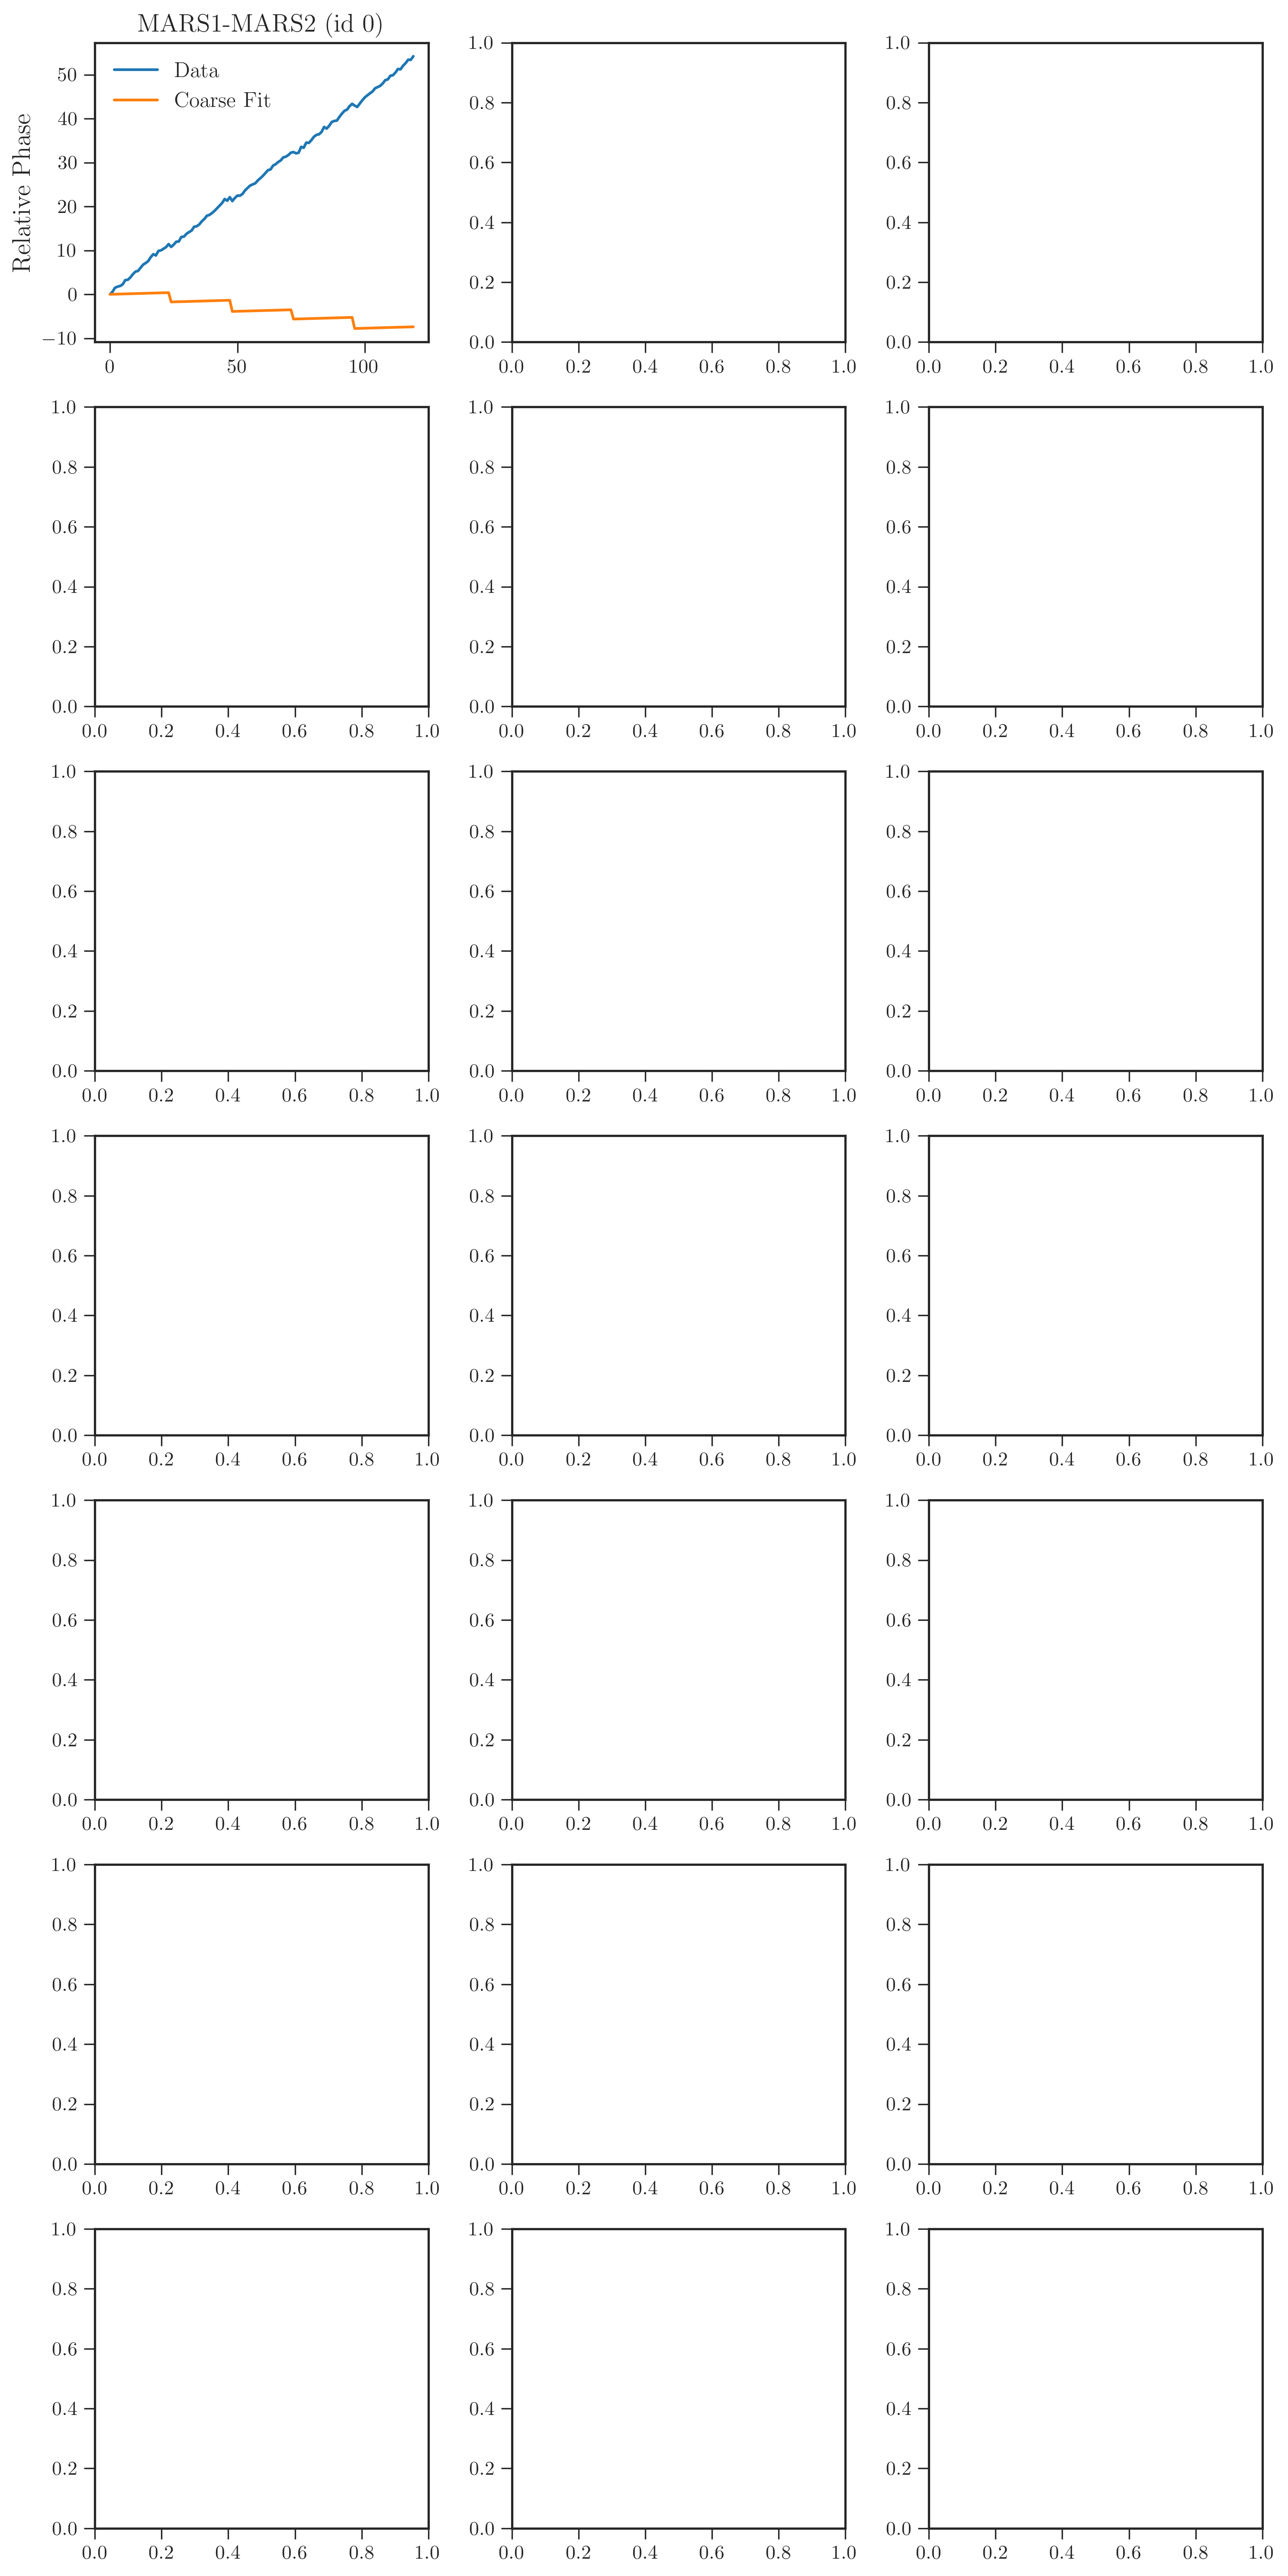

In [ ]:
#plot the ramp guesses vs data
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
fig,ax = plt.subplots(7,3, constrained_layout=True)
fig.set_size_inches(10,20)
ax=np.ravel(ax)

blnum=0
print(nblines)
x = np.arange(nchans)
phased_vis = np.empty_like(vis2[:,:,:])
for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            ax[blnum].set_title(f"{antmap[ai]}-{antmap[aj]} (id {blnum})")
            if i==0:
                tau1=0
            else:
                tau1 = taus_guess0[i-1]
            tau2 = taus_guess0[j-1]
            rel_delay = tau1-tau2
            phase_bline = avg_multi_phase[blnum, :]
            phase_pred = np.unwrap(np.angle(np.exp(2j*np.pi*rel_delay*freqs_normalized)))
            ax[blnum].plot(phase_bline - phase_bline[0], label='Data')
            ax[blnum].plot(phase_pred - phase_pred[0], label='Coarse Fit')
            ax[blnum].set_ylabel('Relative Phase')
            ax[blnum].legend()
            blnum+=1
plt.tight_layout()

noise var shape (1, 183)
data_matrix shape (183, 100, 1)
weight_matrix shape (183, 1)
noise matrix shape (183, 1)
ntimes 183
nchans 100
nblines 1


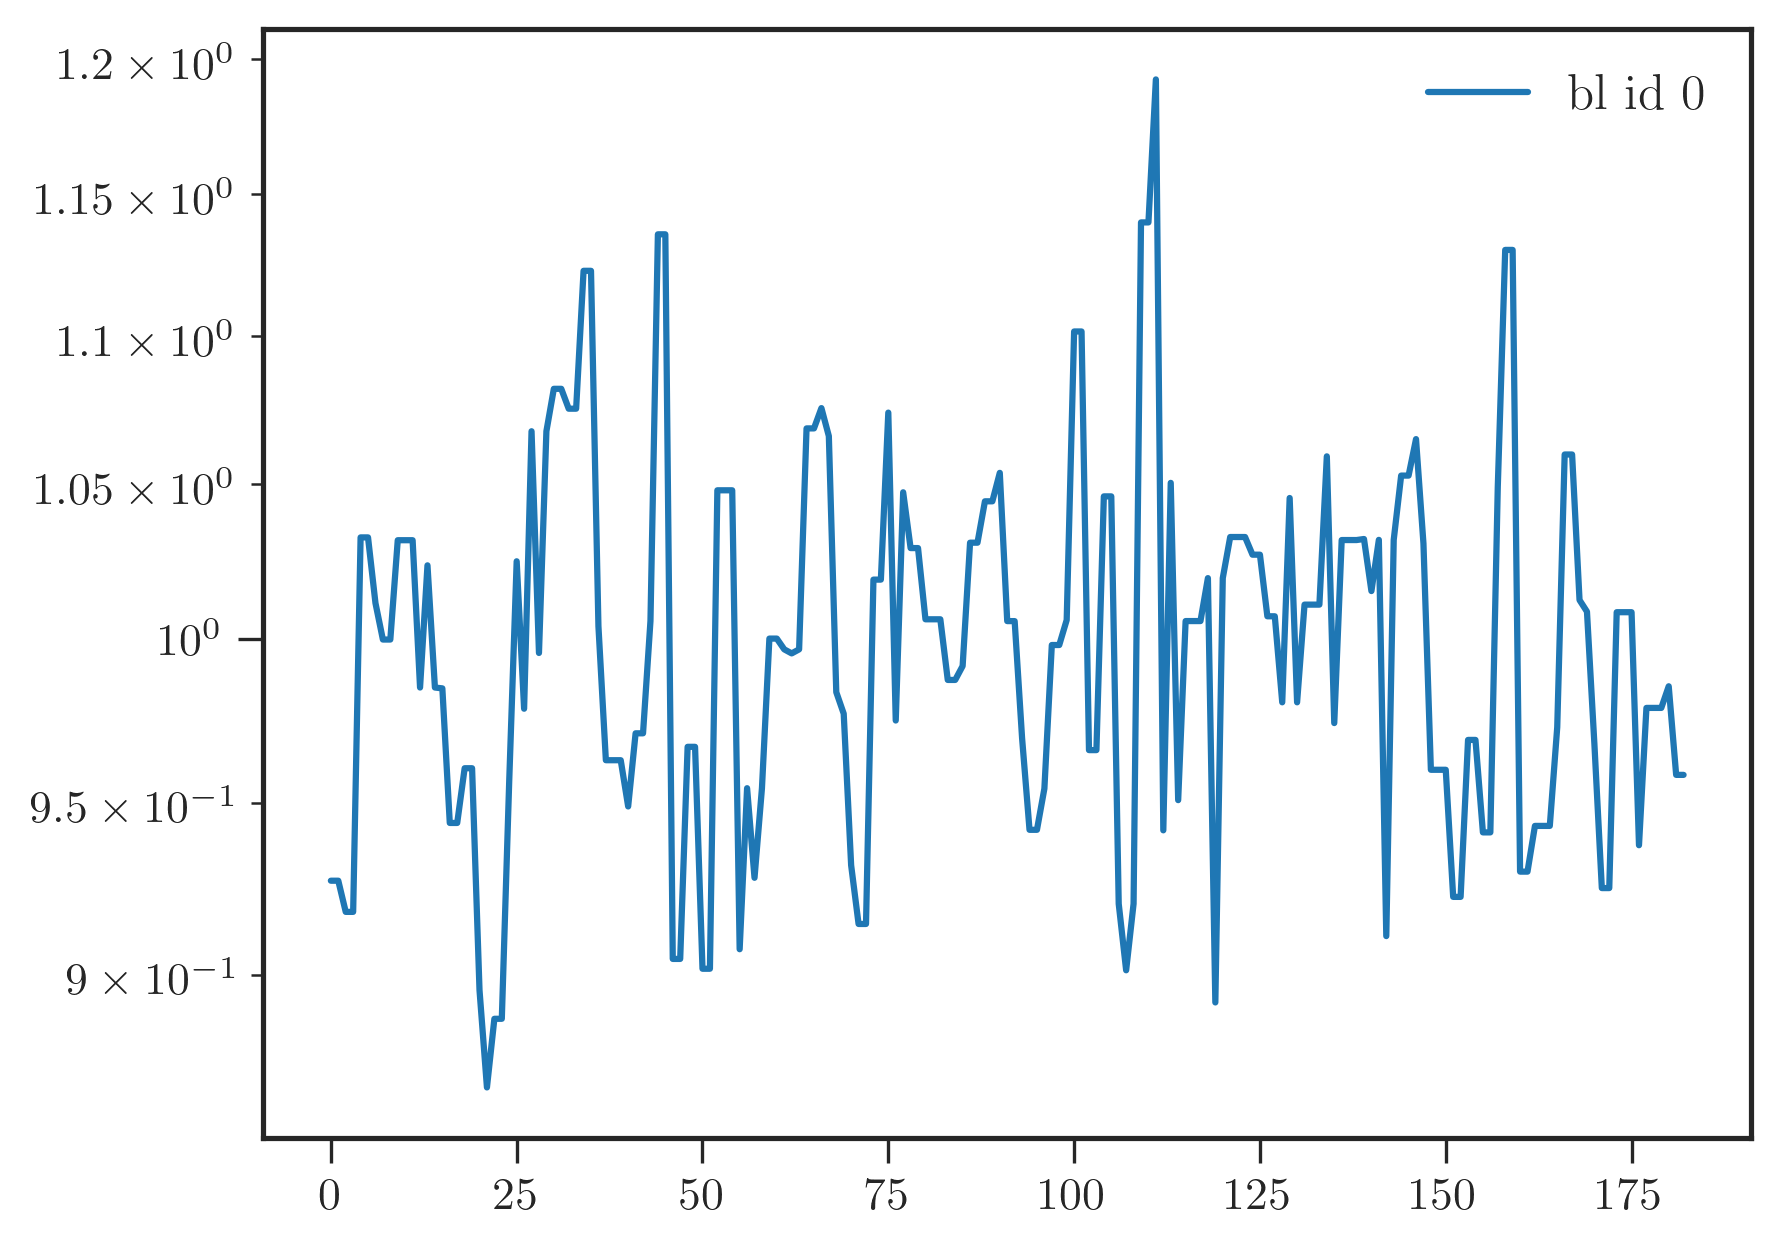

In [15]:
# get noise and fit for each timestamp. plot the weights
noise_var = median_filter(thermal_noise2[:,:],3,axes=1)**2   #why a median filter of just 3??
print('noise var shape', noise_var.shape)

weights = np.sqrt(np.size(noise_var)/noise_var/np.sum(1/noise_var))
angle = np.angle(vis2)

if masking:
    weights = np.tile(weights[:, :, None], (1, 1, nchans))
    weights = np.where(mask2[None, :, :], 0, weights)
    weight_matrix = weights.transpose(1,2,0).copy() #do same for weights so it follows
    phase_unwrapped = angle

    for bl in range(nblines):
        #max is fine since weights either zero or depend on full channel thermal noise
        plt.semilogy(np.max(weights[bl,:, :], axis=1),label=f'bl id {bl}')
    plt.legend()

else:
    phase_unwrapped = angle
    weight_matrix = weights.T.copy()
    for bl in range(nblines):
        plt.semilogy(weights[bl,:],label=f'bl id {bl}')
    plt.legend()

#make baseline fastest moving axis for convenience
data_matrix = phase_unwrapped.transpose(1,2,0).copy()
noise_matrix = noise_var.T.copy()
print('data_matrix shape', data_matrix.shape)
print('weight_matrix shape', weight_matrix.shape)
print('noise matrix shape', noise_matrix.shape)

# make frequencies order 1 for fitting purposes
freqs_normalized = freqs.copy()/1e9

# set up some global variables
assert ntimes == data_matrix.shape[0]
assert nchans == data_matrix.shape[1]
assert nblines == data_matrix.shape[2]
assert nant_used == len(ant_idxs) 
print('ntimes', ntimes)
print('nchans', nchans)
print('nblines', nblines)
#print("nant used:", nant_used)

(183, 100, 1)
-82873.11087465286
-82873.11087465286


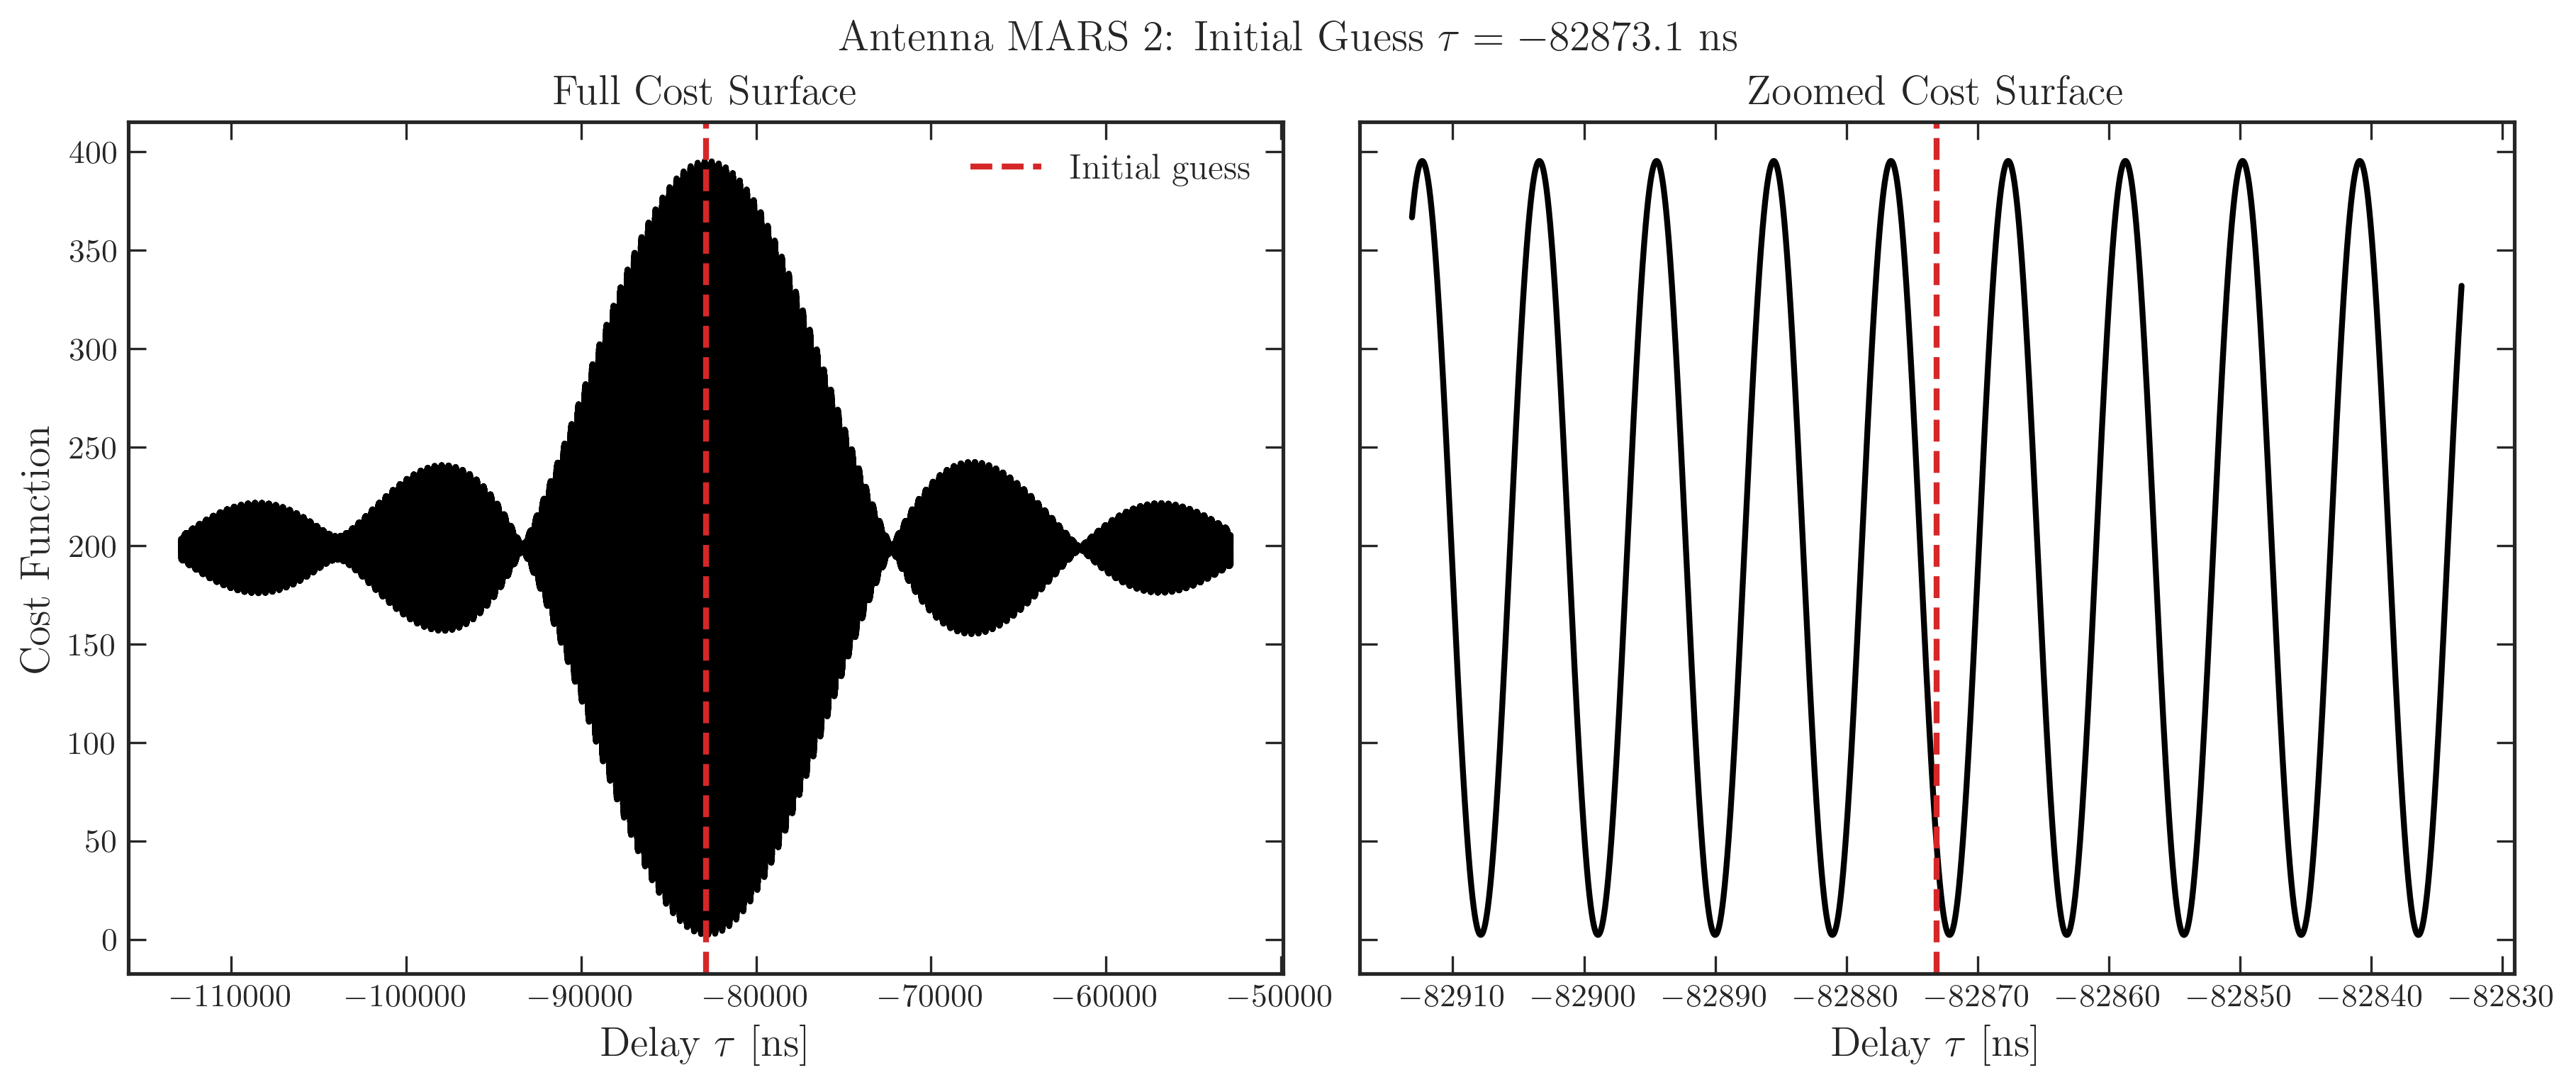

In [17]:
#check the cost surface to see if it makes sense
cost1, cost2, nearest_trough, fig = futils.cost_surface(data_matrix, taus_guess0, freqs_normalized, weight_matrix, antidx=0, timeidx=0, N1=10001, N2=40)

# PHASE TRACKING FIT

starting guess: [-82873.11087465]
done tt=0, time = 0.366
done tt=1, time = 0.000
done tt=2, time = 0.000
done tt=3, time = 0.000
done tt=4, time = 0.000
done tt=5, time = 0.000
done tt=6, time = 0.000
done tt=7, time = 0.000
done tt=8, time = 0.000
done tt=9, time = 0.000
done tt=10, time = 0.000
done tt=11, time = 0.000
done tt=12, time = 0.000
done tt=13, time = 0.000
done tt=14, time = 0.000
done tt=15, time = 0.000
done tt=16, time = 0.000
done tt=17, time = 0.000
done tt=18, time = 0.000
done tt=19, time = 0.000
done tt=20, time = 0.000
done tt=21, time = 0.000
done tt=22, time = 0.000
done tt=23, time = 0.000
done tt=24, time = 0.000
done tt=25, time = 0.000
done tt=26, time = 0.000
done tt=27, time = 0.000
done tt=28, time = 0.000
done tt=29, time = 0.000
done tt=30, time = 0.000
done tt=31, time = 0.000
done tt=32, time = 0.000
done tt=33, time = 0.000
done tt=34, time = 0.000
done tt=35, time = 0.000
done tt=36, time = 0.000
done tt=37, time = 0.000
done tt=38, time = 0.000
d

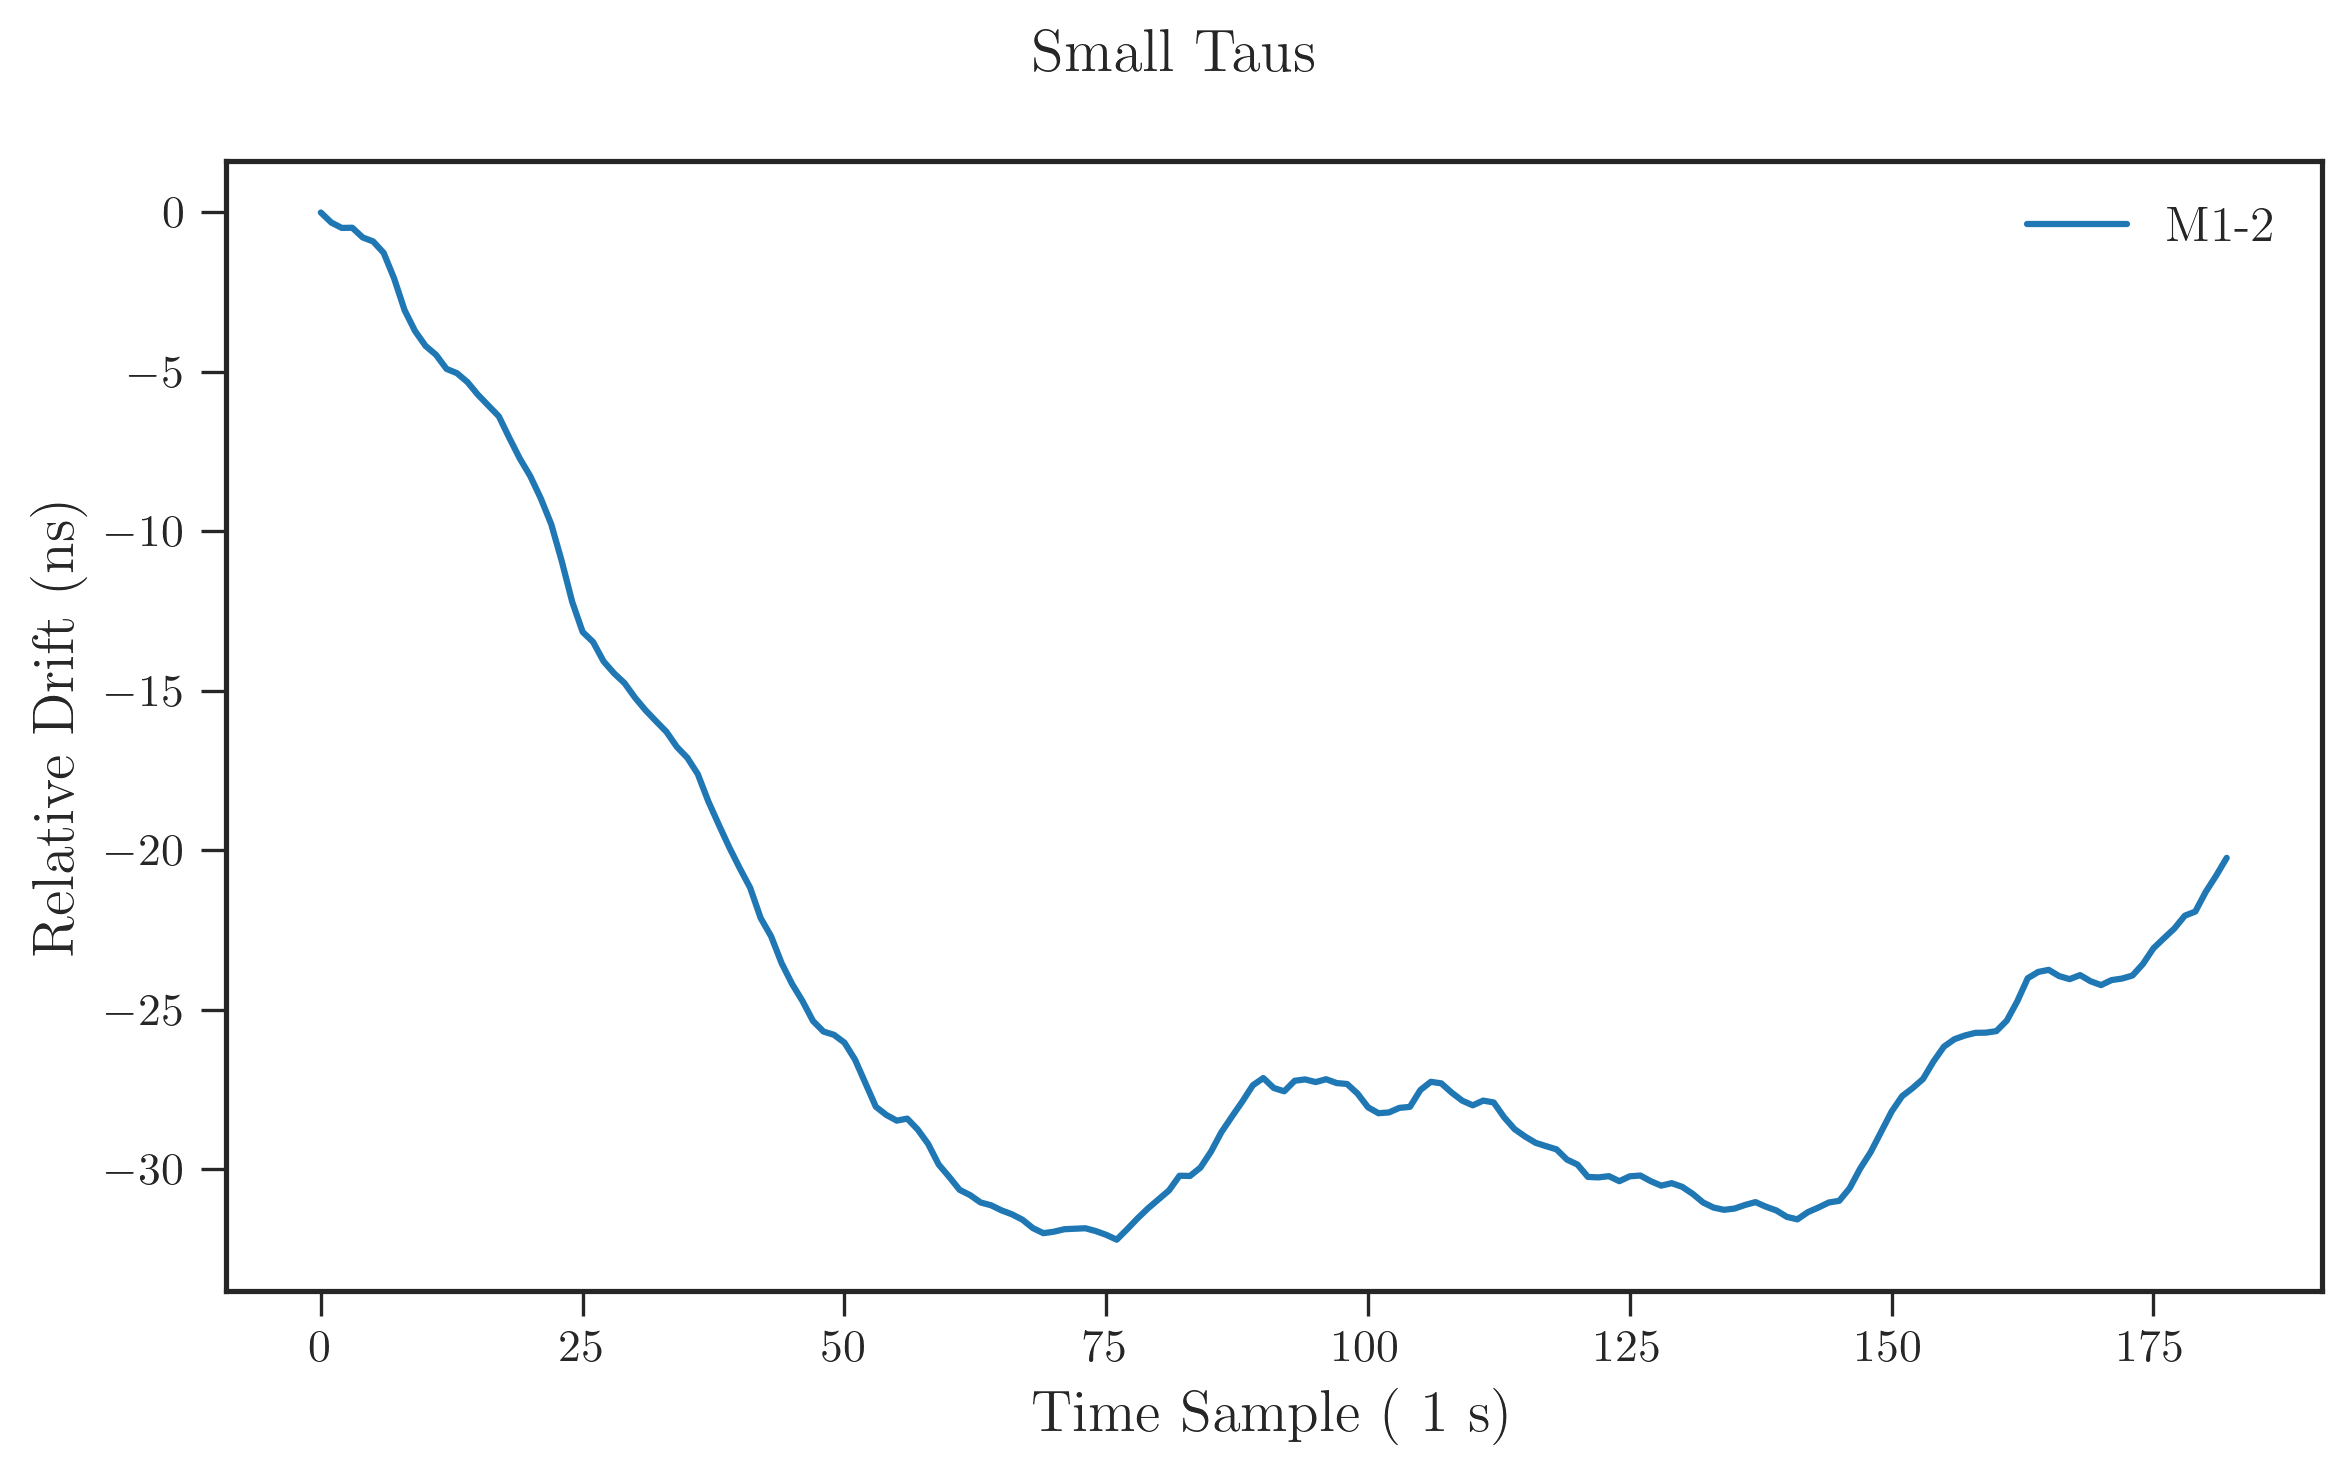

In [ ]:
# array of fitted taus for each time, for each (non-reference) antenna
taus_carrier = np.zeros((ntimes,nant_used-1),dtype='float64')
taus_carrier_errs = np.zeros_like(taus_carrier)

# make some guess about fitted taus (for one sample time)
taus_guess = taus_guess0
print('starting guess:', taus_guess0)

for tt in range(ntimes):
    ydata = data_matrix[tt,:,:].ravel()
    if masking:
        weights = weight_matrix[tt,:,:]
    else:
        weights = weight_matrix[tt,:]
    t1=time.time()

    tau_fit_params = least_squares(futils.func, taus_guess, args=(ydata, freqs_normalized, weights),
                                                        jac=futils.jac2,
                                                        method='lm',
                                                        ftol=1e-06, 
                                                        xtol=1e-06, 
                                                        gtol=1e-06, 
                                                        loss='linear')

    t2=time.time()
    taus_carrier[tt,:] = tau_fit_params['x']
    taus_carrier_errs[tt,:] = tau_fit_params['errors']
    taus_guess = tau_fit_params['x']
    
    print(f"done tt={tt}, time = {t2-t1:5.3f}")
    #print('new guess:', taus_guess)

fig, ax = plt.subplots(figsize=(8,5))
labels=['M1-2', 'M1-4', 'M1-5', 'M1-6', 'M1-7', 'M1-8']
tausz_carrier = np.zeros_like(taus_carrier)
for antidx in range(nant-1):
    ts = taus_carrier[:,antidx] - taus_carrier[0,antidx]
    tausz_carrier[:,antidx] = ts
    ax.plot(ts, label=labels[antidx])
    ax.set_xlabel('Time Sample (~1 s)')
    ax.set_ylabel('Relative Drift (ns)')
ax.legend()
plt.suptitle('Small Taus')
plt.tight_layout()

In [ ]:
print(tausz_carrier.shape)

(183, 1)


In [ ]:
max_tau_jump = np.max(np.abs(np.diff(np.concatenate(tausz_carrier, axis=0), axis=0)))
print(max_tau_jump)

1.2794276585045736


# CHECK PEAK TRACKING JUMPS

In [18]:
#let's verify with cost surfaces that for any time sample there really is a convergence to the nearest trough
#BEFORE FIT (using previous value)
test_timesample = 11
cost1, cost2, nearest_trough, fig = futils.cost_surface(data_matrix, taus_carrier[test_timesample-1], freqs_normalized, weight_matrix, antidx=0, timeidx=test_timesample, N1=10001, N2=40)

NameError: name 'data_matrix' is not defined

(183, 100, 1)
-82876.59975585969
-82876.59975585969


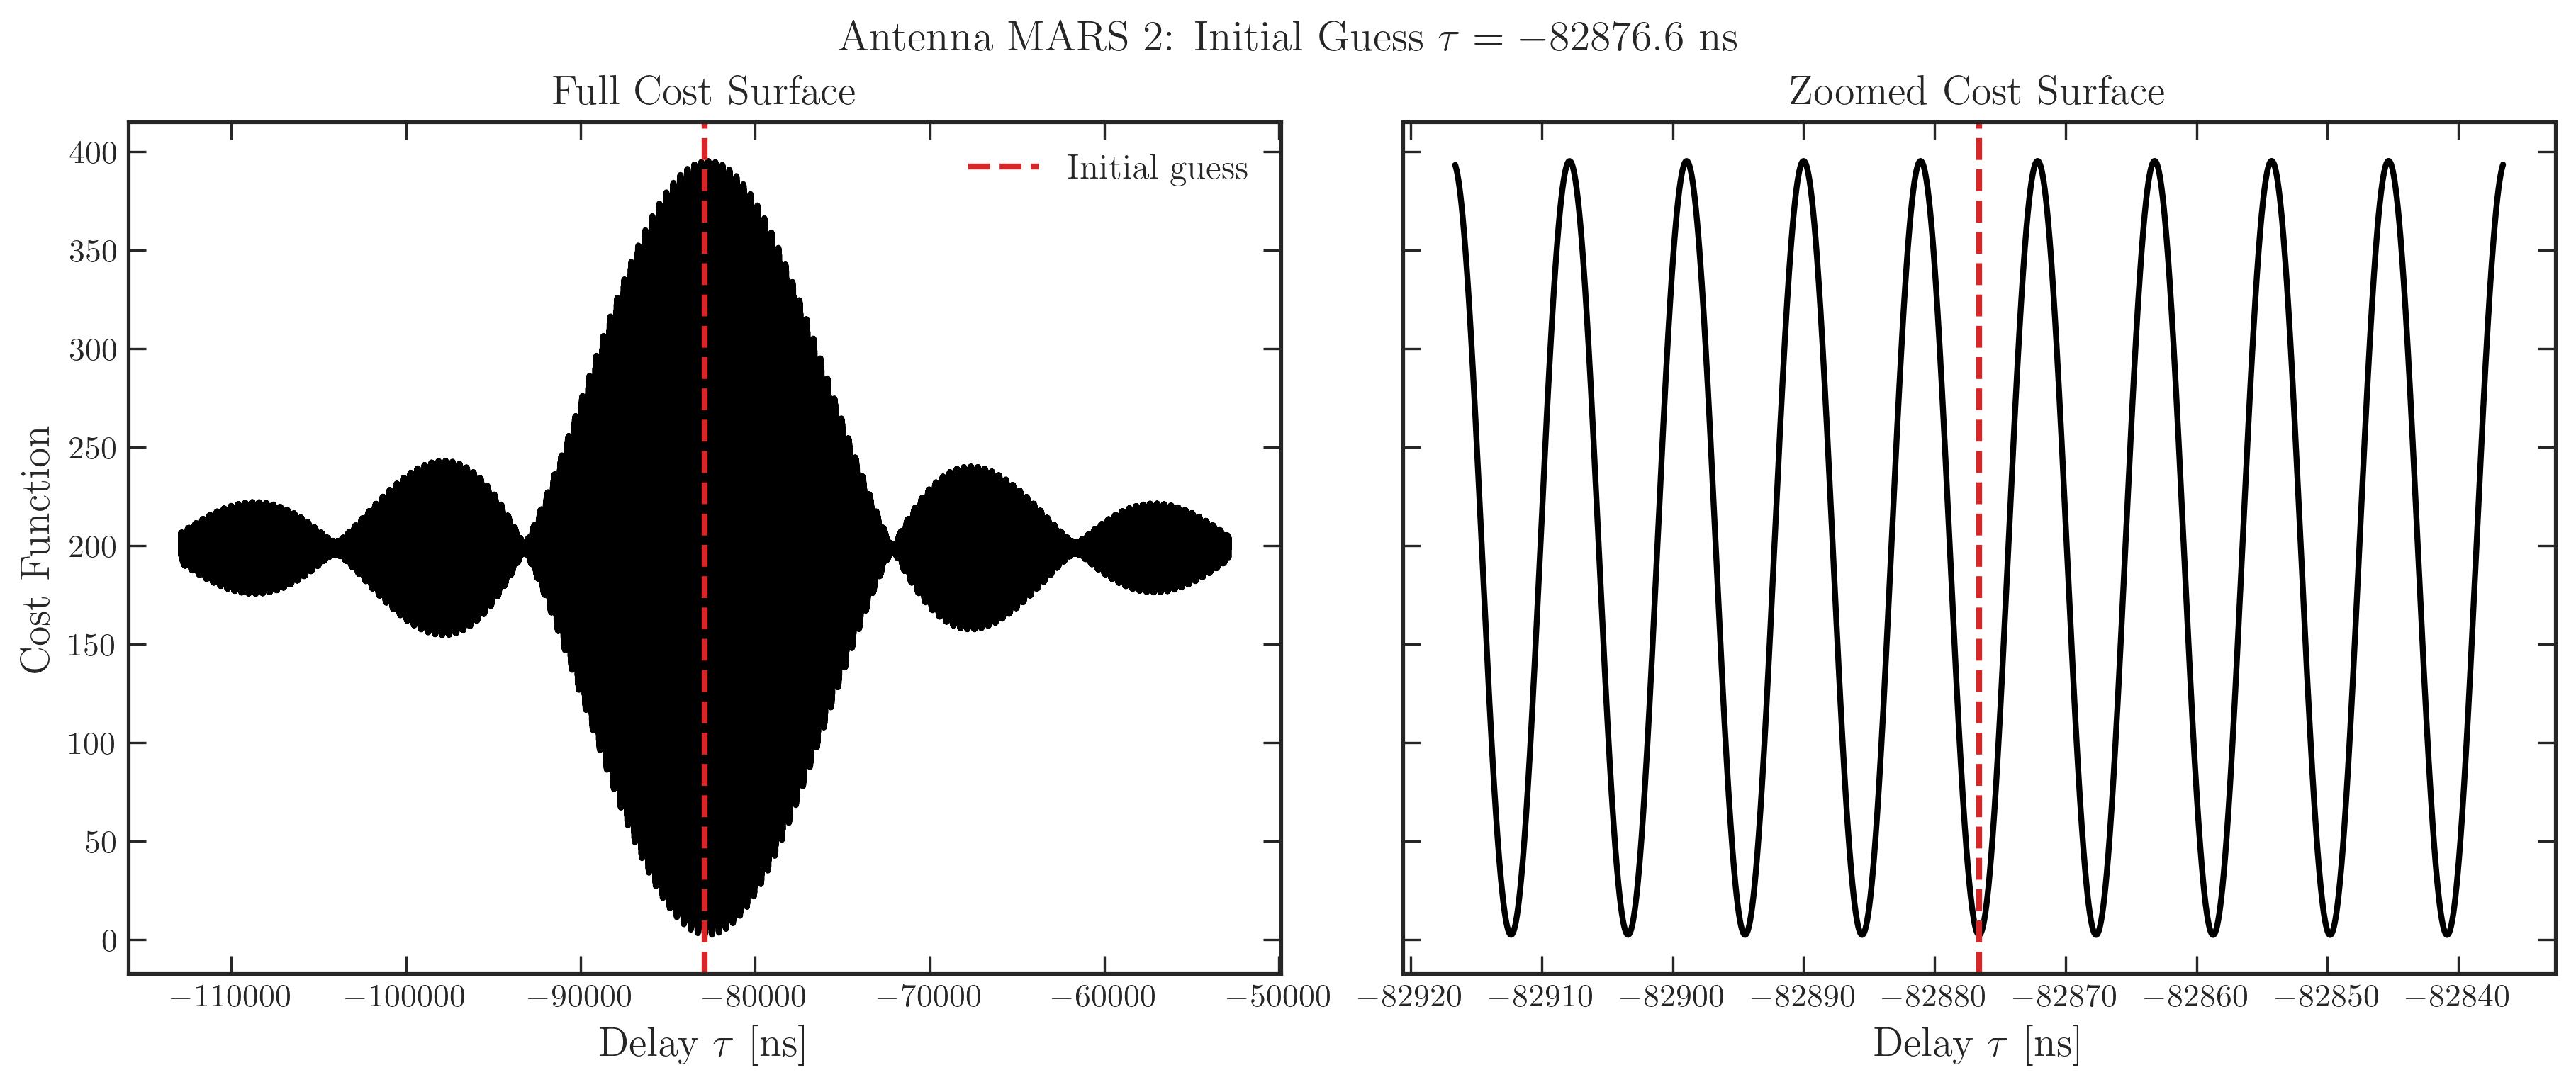

In [ ]:
#AFTER FIT (using fitted value)
cost1, cost2, nearest_trough, fig = futils.cost_surface(data_matrix, taus_carrier[test_timesample], freqs_normalized, weight_matrix, antidx=0, timeidx=test_timesample, N1=10001, N2=40)

In [85]:
# fig, axes = plt.subplots(int(taus_small.shape[1]/2), 2, sharex=True, sharey=True, figsize=(16, 8))
# axes = axes.ravel()
# for i, ax in enumerate(axes):
#     ax.set_title(f'bline {i}')
#     ax.plot(np.diff(taus_small[:, i]))
#     ax.set_ylabel(r'$\Delta \tau$ (ns)')

# axes[-1].set_xlabel(f'Time Sample (~ {int(acclen*T_SPECTRA*1e3)} ms)')
# plt.tight_layout()

In [44]:
#do we need to unwrap???
# have the option to use either to get the final proper offset value.
#taus_unwrapped = np.unwrap(np.angle(np.exp(1j*taus_fitted.reshape(-1,nant_used-1)*2*np.pi*freqs_normalized.mean())),axis=0)/(2*np.pi*freqs_normalized.mean())

# plot the relative delays of the other antenna with respect to the reference antenna
# plt.plot(taus_unwrapped,label=labels)
# plt.ylabel('Relative Delay (ns)')
# plt.xlabel('Time (s)')
# plt.legend(loc='upper right')
# plt.suptitle('Unwrapped Taus')

# ALIGN PHASES

1


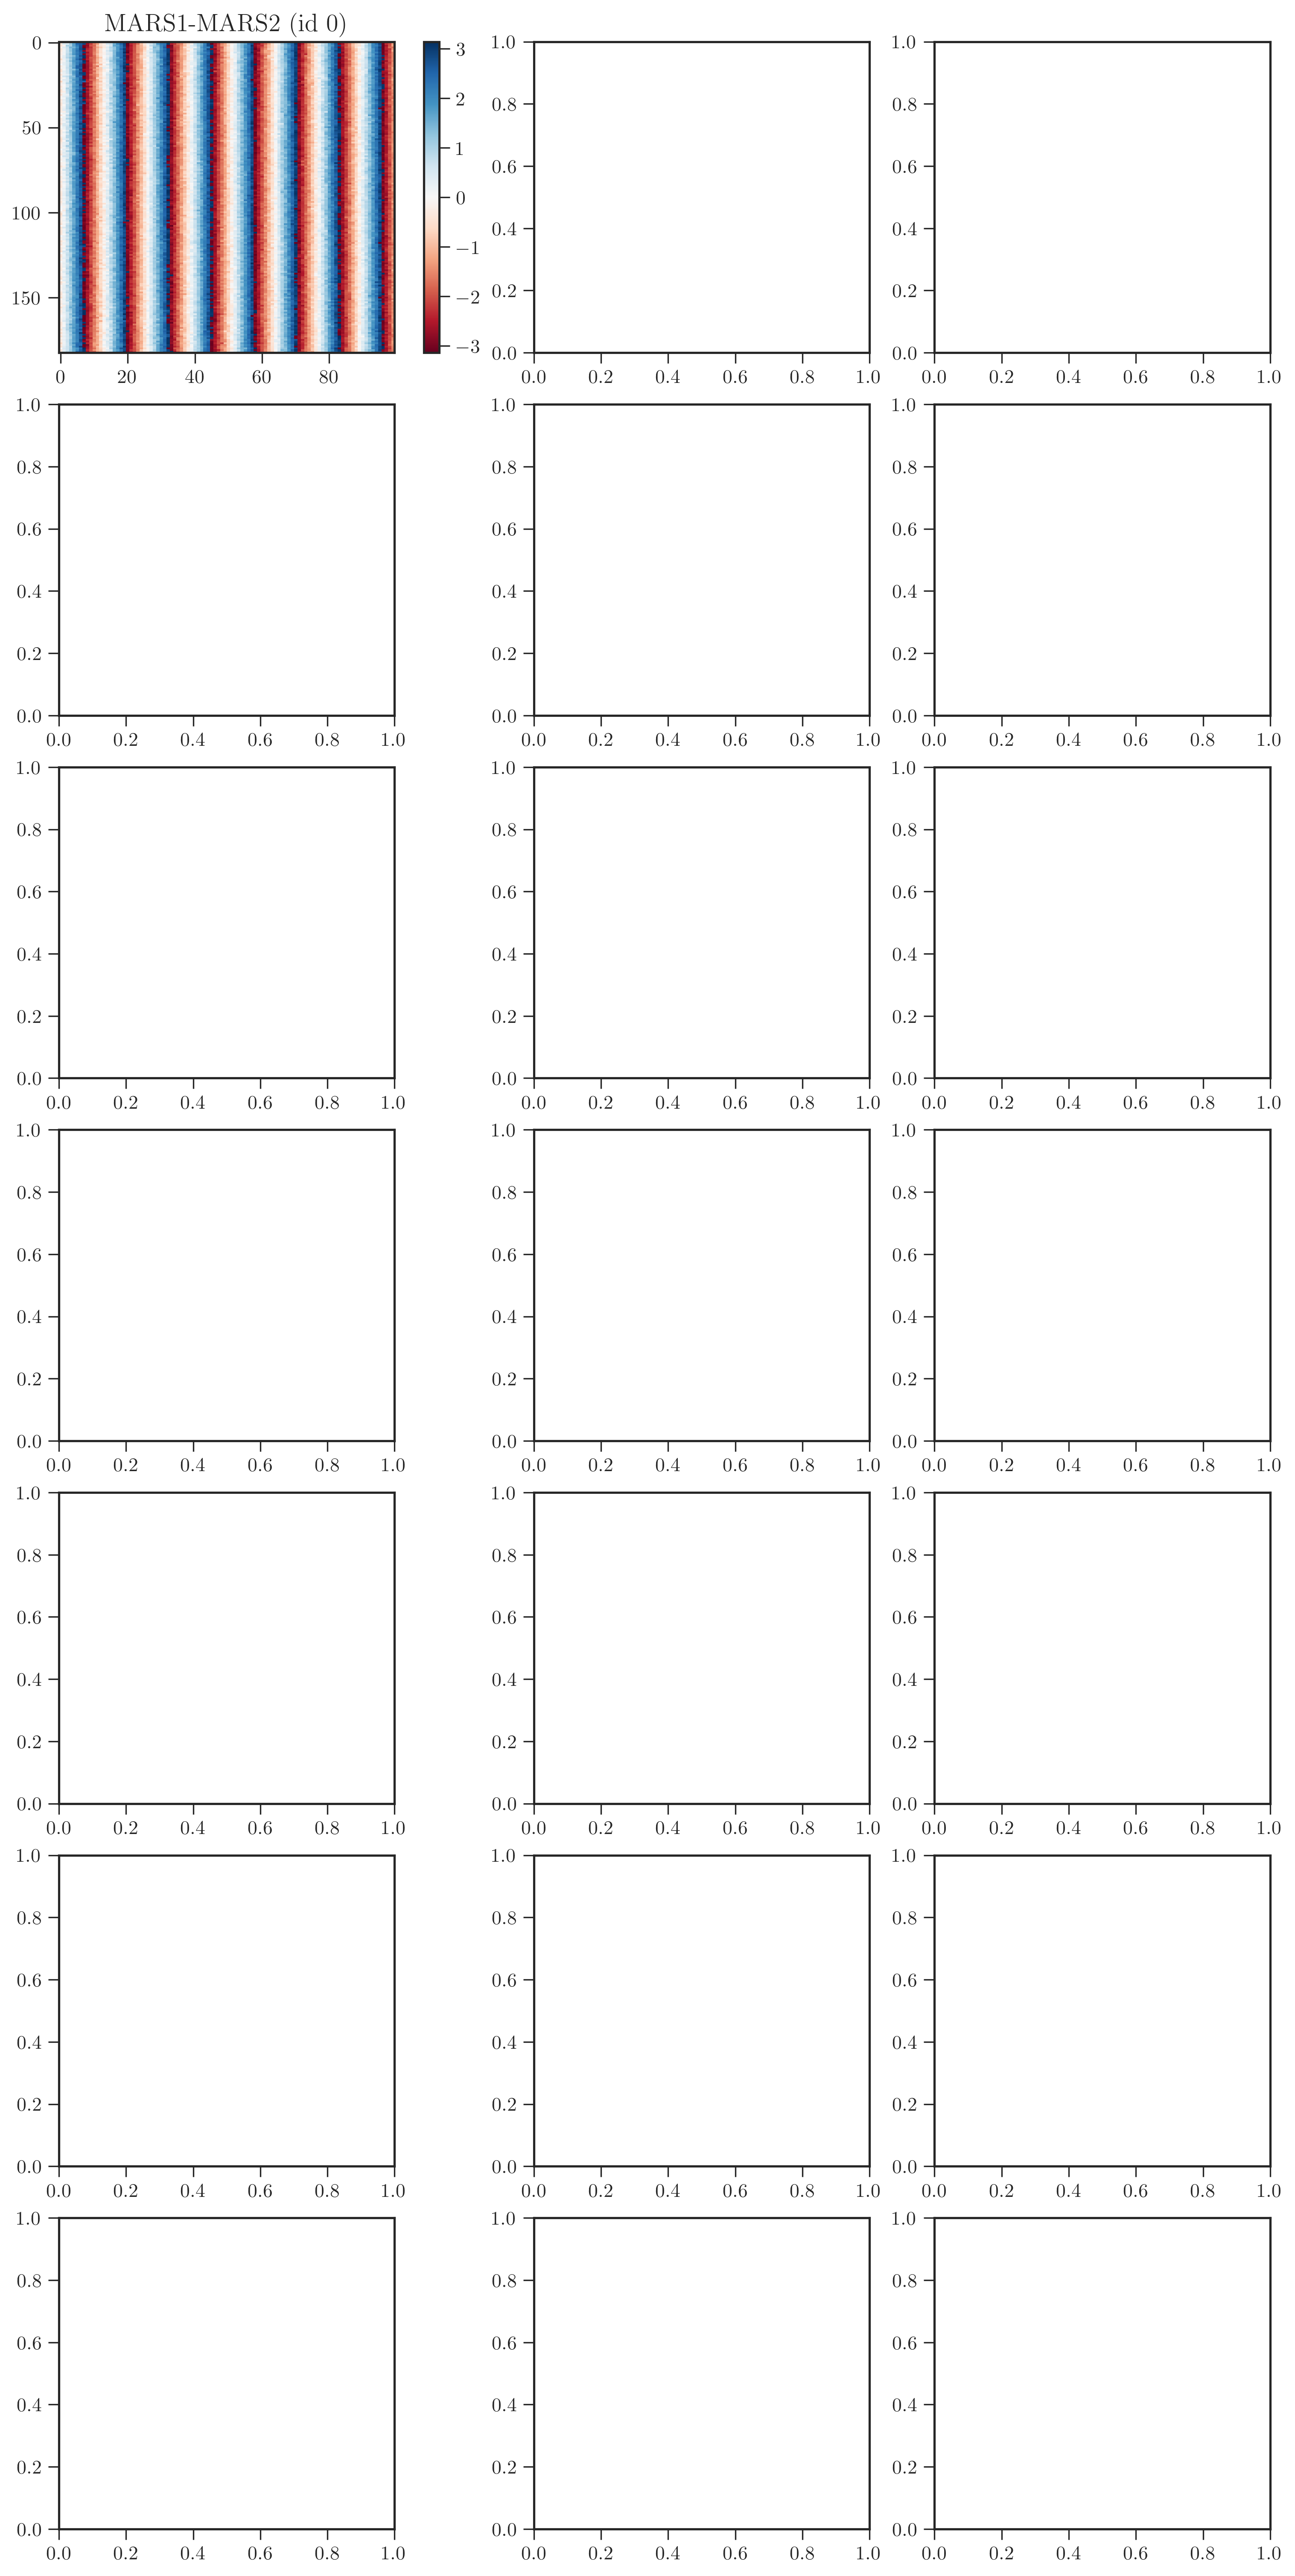

In [ ]:
#generate aligned phase plots for each baseline with fitted taus
#in the meantime also phases the visibilities to align them

antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
fig,ax = plt.subplots(7,3, constrained_layout=True)
fig.set_size_inches(10,20)
ax=np.ravel(ax)

blnum=0
print(nblines)
x = np.arange(nchans)
phased_vis = np.empty_like(vis2[:,:,:])
for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            if i==0:
                tau1=0
            else:
                tau1 = tausz_carrier[:,i-1]
            tau2 = tausz_carrier[:,j-1]
            rel_delay = tau1-tau2
            ax[blnum].set_title(f"{antmap[ai]}-{antmap[aj]} (id {blnum})")
            phased_vis[blnum,:,:] = vis2[blnum,:,:]*np.exp(-2j*np.pi*freqs_normalized[None,:]*rel_delay[:,None])
            if masking:
                phased_vis_masked = np.ma.masked_where(mask2, np.angle(phased_vis[blnum,:,:]))
                img = ax[blnum].imshow(phased_vis_masked, aspect='auto', interpolation='none', cmap='RdBu')
                cbar=plt.colorbar(img,ax=ax[blnum])
            else:
                img=ax[blnum].imshow(np.angle(phased_vis[blnum,:,:]),aspect='auto',interpolation='none',cmap='RdBu')
                cbar=plt.colorbar(img,ax=ax[blnum])
            blnum+=1
# plt.tight_layout()

# STACKED LINEAR FIT

In [25]:
#take average across time once aligned to boost SNR
if masking:
    #introduce mask 3 or something to check if there are enough points ALONG TIME. 
    #if bad, just interpolate after the fact and assign high noise value
    phased_vis_masked = np.ma.array(phased_vis, mask=np.broadcast_to(mask2[None, :, :], phased_vis.shape))
    avg_multi_vis = phased_vis_masked.mean(axis=1)
else:
    avg_multi_vis = np.mean(phased_vis, axis=1)


#avg_multi_vis = np.mean(phased_vis,axis=1)
# avg_multi_vis = np.median(phased_vis,axis=1)

#now have very clean phase ramp with super low noise
avg_multi_vis = avg_multi_vis.T.copy()
#plt.plot(np.unwrap(np.angle(avg_multi_vis),axis=0))
print(avg_multi_vis.shape)


#get that noise by fitting a line and getting std of residuals
noise_matrix_avg = np.zeros((1,nblines),dtype='float64')
for bl in range(nblines):
    y = np.unwrap(np.angle(avg_multi_vis[:,bl]))
    m, c = np.polyfit(x,y, 1)
    residual = y - (m*x + c)
    noise_matrix_avg[0,bl] = np.std(residual)
print(noise_matrix_avg)

(100, 1)
[[0.01132327]]


In [ ]:
#can now just fit linearly using normal equations
data_matrix = np.unwrap(np.angle(avg_multi_vis),axis=0)
data_matrix = data_matrix.reshape(1,nchans,nblines)

Ag = futils.get_grammian(nant)
print(data_matrix.shape)

AtA2,Atd2 = futils.get_AtA_Atd(data_matrix,
                            Ag,
                            noise_matrix_avg**2,
                            freqs_normalized,
                            nant,
                            nchans,
                            1,
                            fit_constant=True)

AtA_inv2 = np.linalg.inv(AtA2)

mfit2 = AtA_inv2 @ Atd2
print(mfit2)

# Total parameters for tau: ntime * (nant-1)
bs = nant - 1
tau0_carrier = mfit2[:1 * bs]
phi_linear2 = mfit2[1 * bs:]
errs_all = np.sqrt(np.diag(AtA_inv2))
tau0_carrier_errs = errs_all[:nant-1]

print(tau0_carrier)
print(tau0_carrier_errs)

(1, 100, 1)
Snu 70.33511636391509 Snu2 49.470288931073185
[-82719.60582149  58156.69404054]
[-82719.60582149]
[6.54642587]


In [27]:
wts = np.ones(183)
print(data_matrix.shape)

(1, 100, 1)


(1, 100, 1)
-82719.60582149029
-82719.60582149029


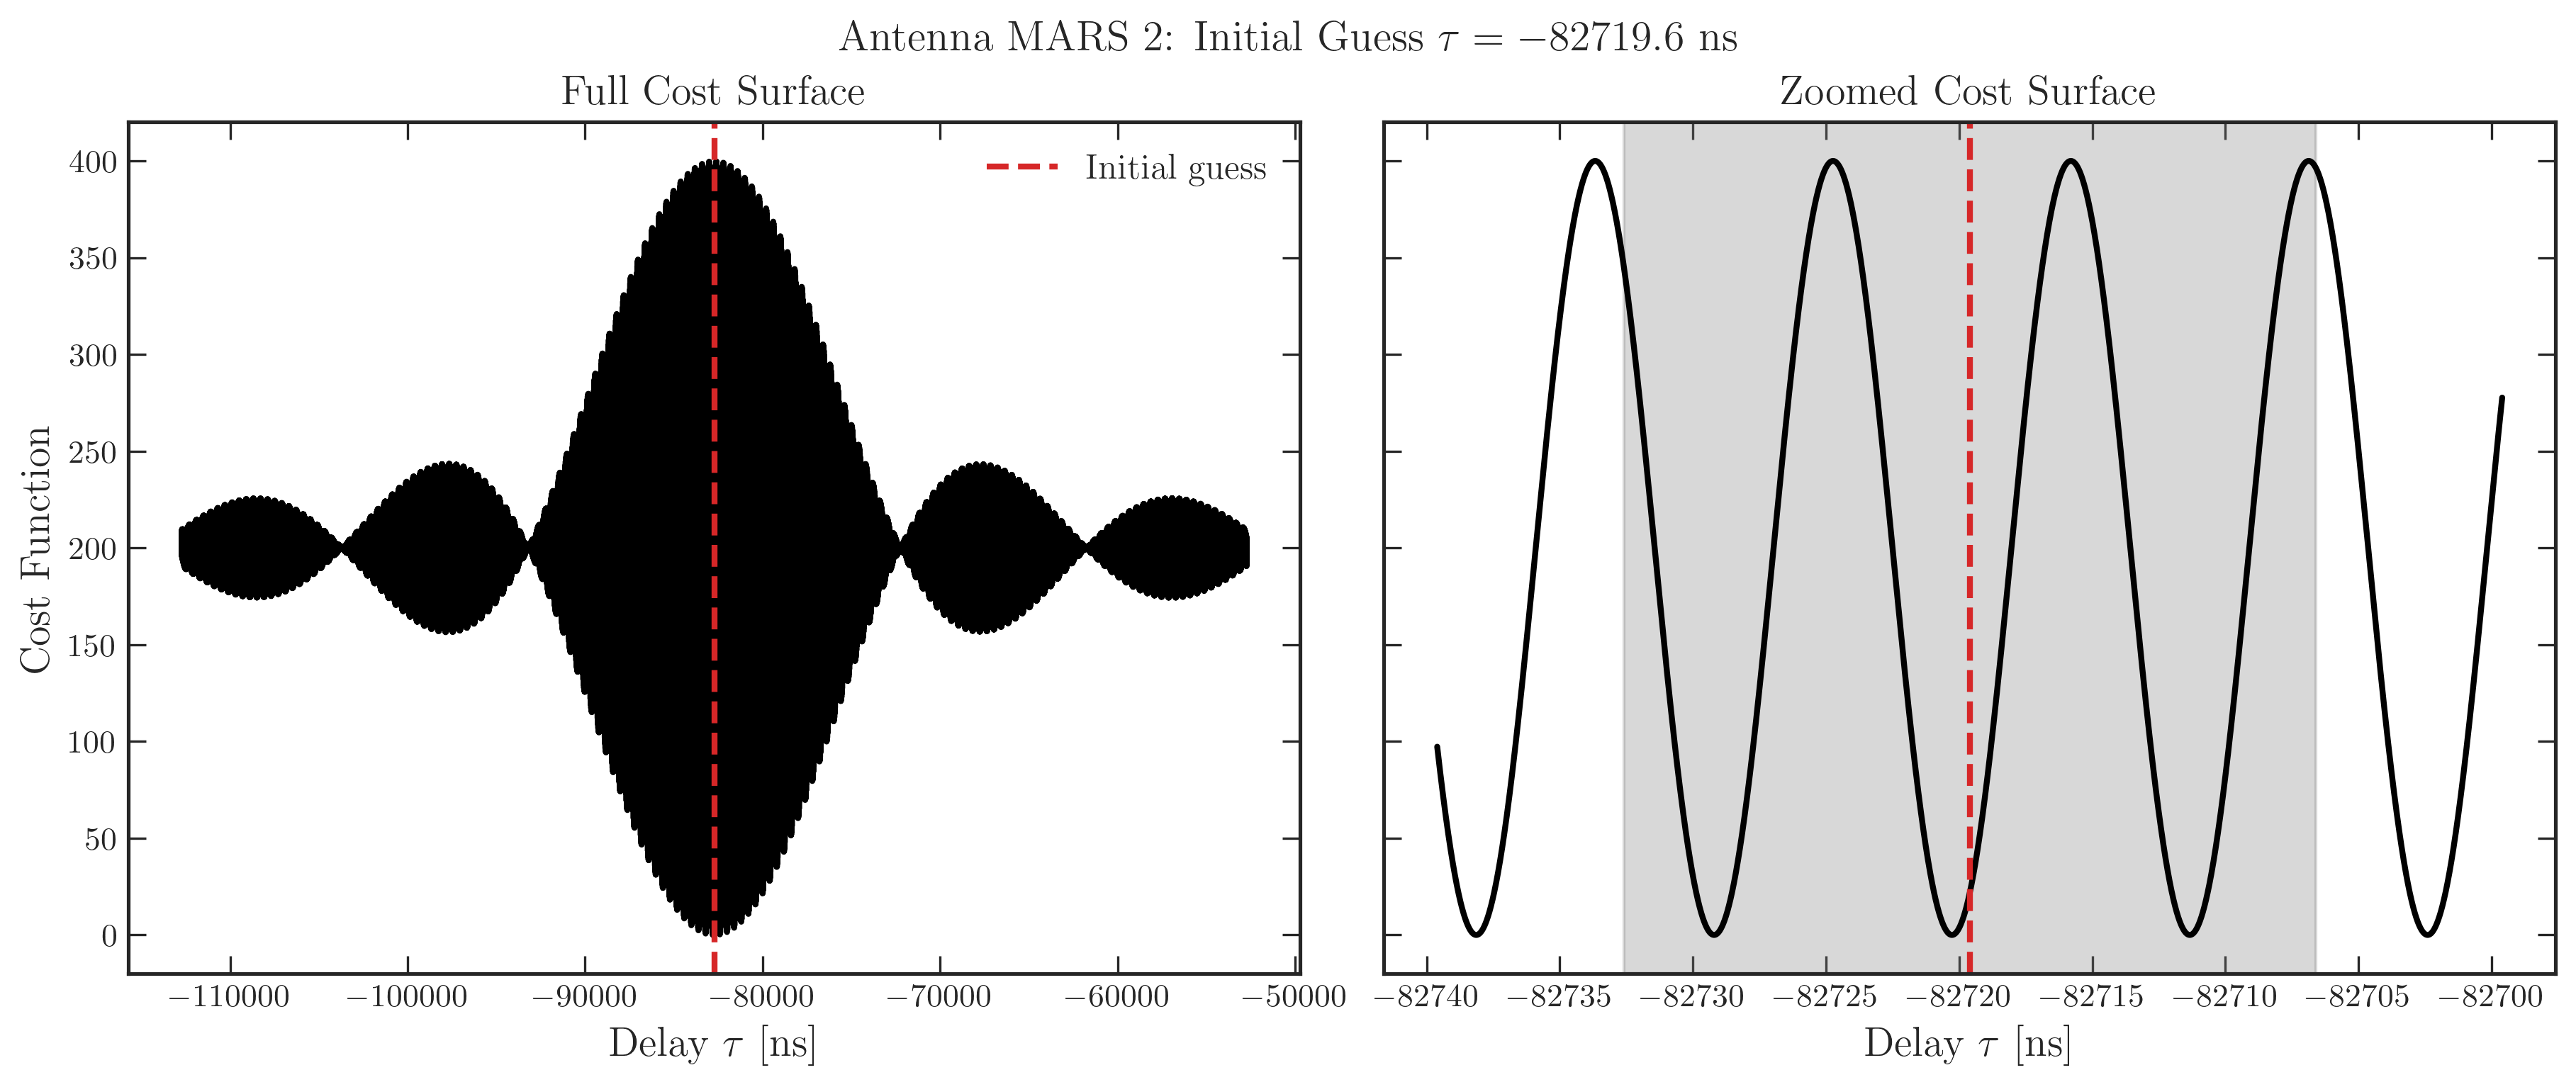

In [ ]:
#check that we are on the correct carrier peak
cost1, cost2, trough, fig = futils.cost_surface(data_matrix, tau0_carrier, freqs_normalized, wts, antidx = 0, timeidx=0, N1=10001, N2=20, err=3*4.33)
fig.savefig('./images/cost_surface.png')

In [ ]:
print(trough)
print(trough-tau0_carrier)

[ -3056.70358876 -21414.3447176    7766.90171145  -3630.52967367
  -4092.97803966   8418.61322449]
[-0.4  0.   0.   0.   0.   0. ]


In [ ]:
#fit onto nearest carrier peak
print('starting guess:', tau0_carrier)
ydata = data_matrix.ravel()
tau_fitted = least_squares(futils.func, tau0_carrier, args=(ydata, freqs_normalized, wts),
                                                    jac=futils.jac,
                                                    method='lm',
                                                    ftol=1e-06, 
                                                    xtol=1e-06, 
                                                    gtol=1e-06, 
                                                    loss='linear')
print('fitted value', tau_fitted['x'][0])
tau0_final = tau_fitted['x'][0]

starting guess: [-82719.60582149]
fitted value -82720.27285768601


# DOWNCONVERTED PER-TIME

In [ ]:
# array of fitted taus for each time, for each (non-reference) antenna
taus_downc = np.zeros((ntimes,nant_used-1),dtype='float64')
taus_downc_errs = np.zeros_like(taus_downc)

# make some guess about fitted taus (for one sample time)
taus_guess = taus_guess0
print('starting guess:', taus_guess0)

for tt in range(ntimes):
    ydata = data_matrix[tt,:,:].ravel()
    if masking:
        weights = weight_matrix[tt,:,:]
    else:
        weights = weight_matrix[tt,:]
    t1=time.time()

    tau_fit_params = least_squares(futils.func, taus_guess, args=(ydata, freqs_normalized, weights, True),
                                                        jac=futils.jac2,
                                                        method='lm',
                                                        ftol=1e-06, 
                                                        xtol=1e-06, 
                                                        gtol=1e-06, 
                                                        loss='linear')

    t2=time.time()
    taus_downc[tt,:] = tau_fit_params['x']
    taus_guess = tau_fit_params['x']
    
    print(f"done tt={tt}, time = {t2-t1:5.3f}")
    #print('new guess:', taus_guess)

fig, ax = plt.subplots(figsize=(8,5))
labels=['M1-2', 'M1-4', 'M1-5', 'M1-6', 'M1-7', 'M1-8']
tausz_downc = np.zeros_like(taus_downc)
for antidx in range(nant-1):
    ts = taus_downc[:,antidx] - taus_downc[0,antidx]
    tausz_downc[:,antidx] = ts
    ax.plot(ts, label=labels[antidx])
    ax.set_xlabel('Time Sample (~1 s)')
    ax.set_ylabel('Relative Drift (ns)')
ax.legend()
plt.ylabel('Small Downconverted Taus')
plt.tight_layout()

In [ ]:
#save the fitted values!
np.savez('/scratch/thomasb/sim_finetiming/delay_results_v2.npz', 
        taus_carrier = tausz_carrier,
        taus_carrier_errs = taus_carrier_errs, 
        net_carrier = tau0_carrier,
        net_carrier_errs = tau0_carrier_errs,
        taus_downc = tausz_downc, 
        taus_downc_errs = taus_downc_errs,
        #net_downc = tau0_downc,
        #net_downc_errs =  tau0_downc_errs
        )

# CHECK NEAREST PEAK FIT

In [138]:
#check if nearest carrier peak makes sense
print('difference (ns):', np.abs(tau0 - tau0_final))
print('difference (rads):', np.abs(tau0 - tau0_final)*2*np.pi * 0.111)

difference (ns): [0.6670362]
difference (rads): [0.46521343]


(1, 100, 1)
-82720.27285768601


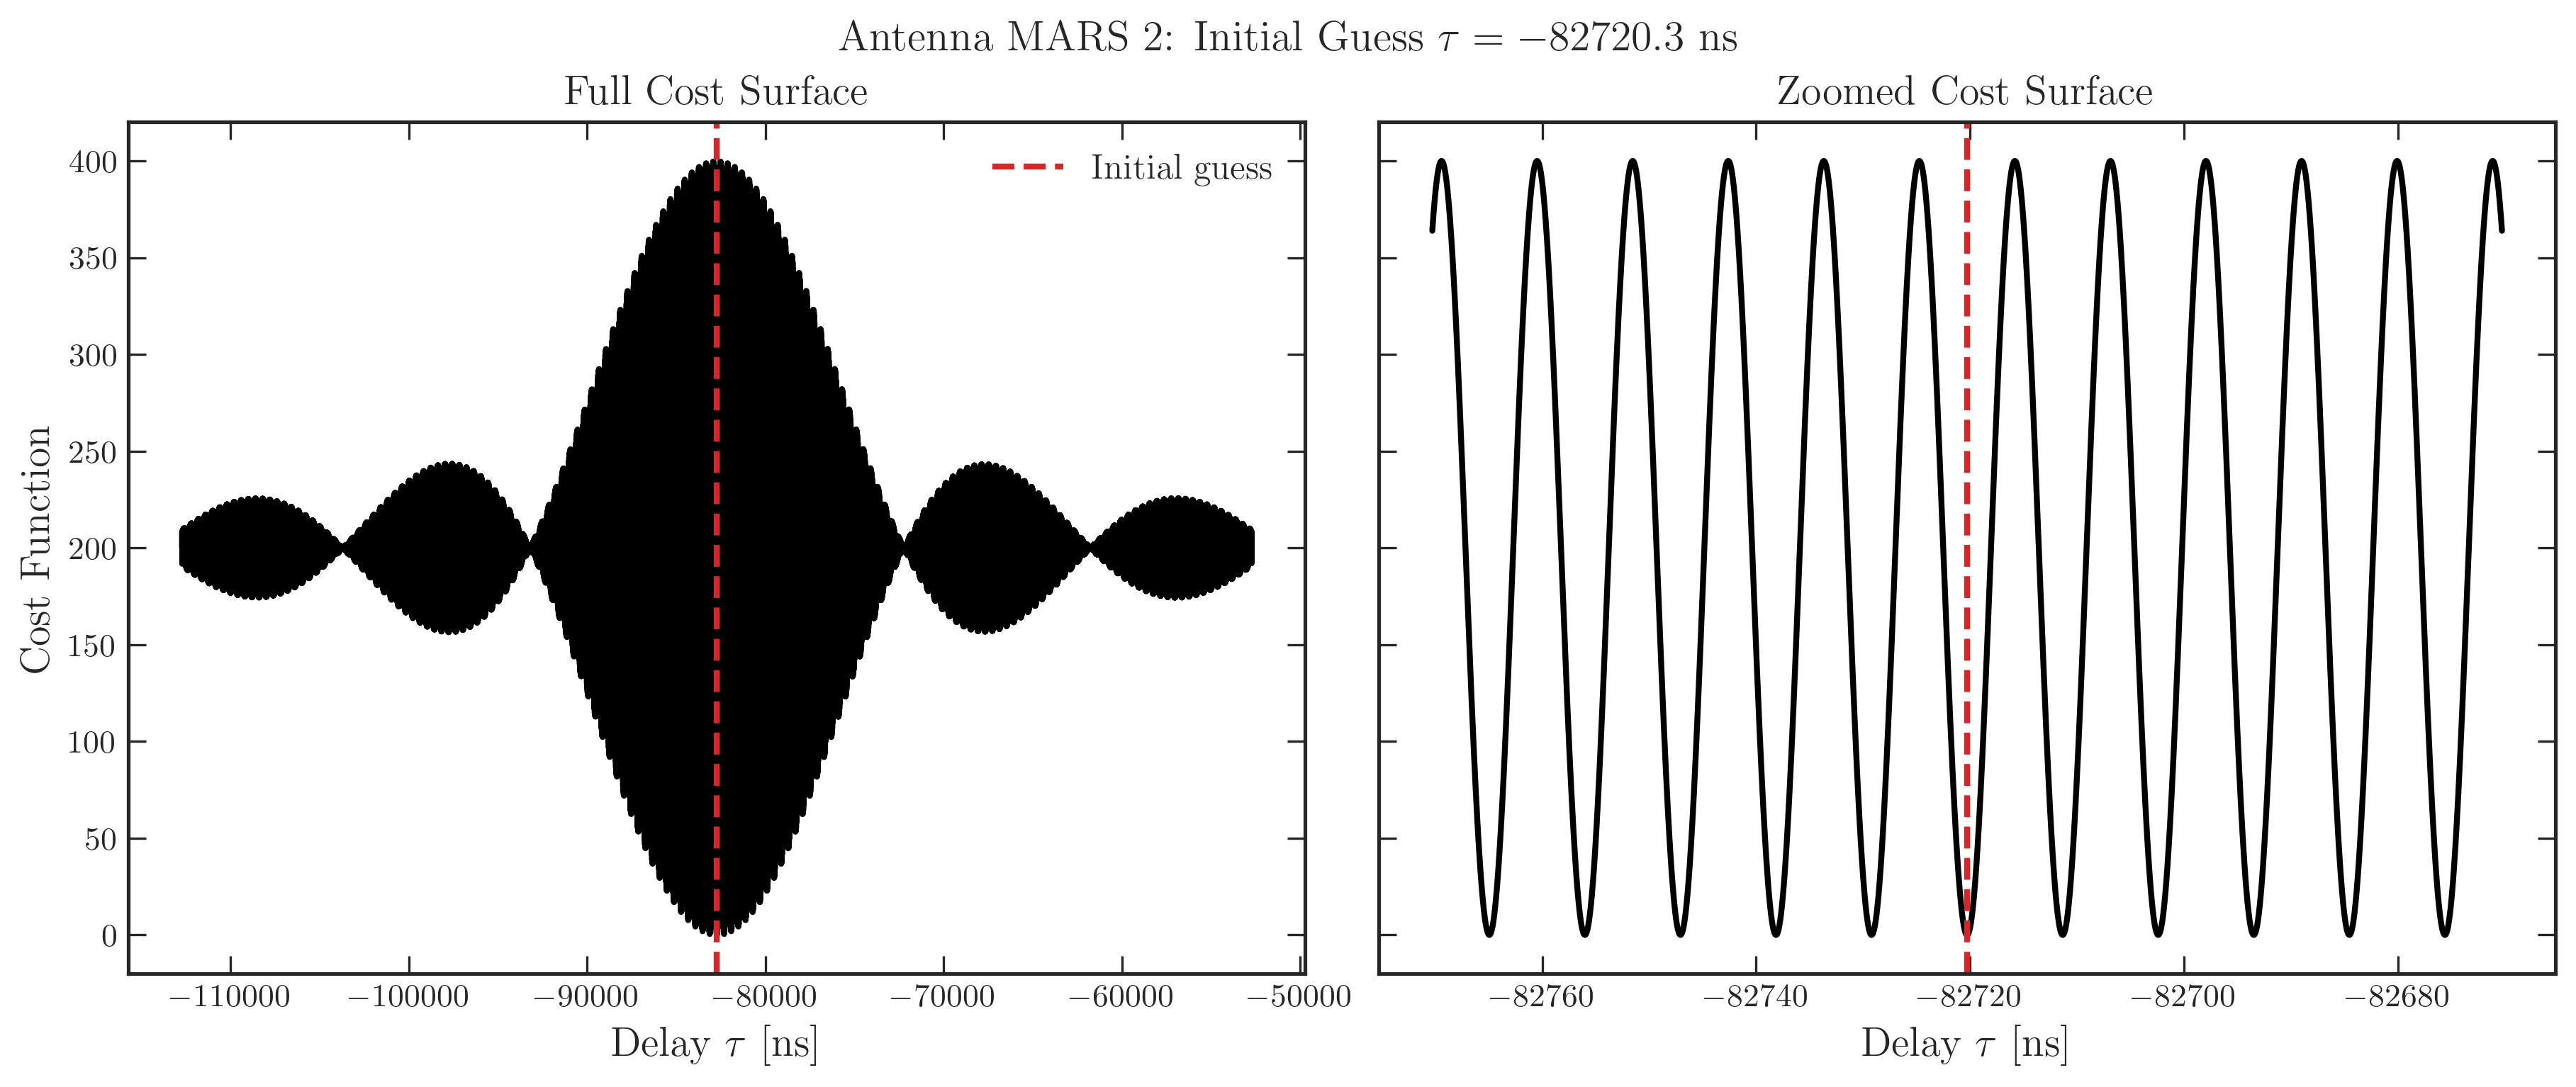

In [141]:
#check that we are on the correct carrier peak
cost1, cost2, trough, fig = cost_surface(data_matrix, [tau0_final], freqs_normalized, wts, antidx = 0, timeidx=0, N1=10001, N2=40)

# PLOTS PLOTS PLOTS BABAY

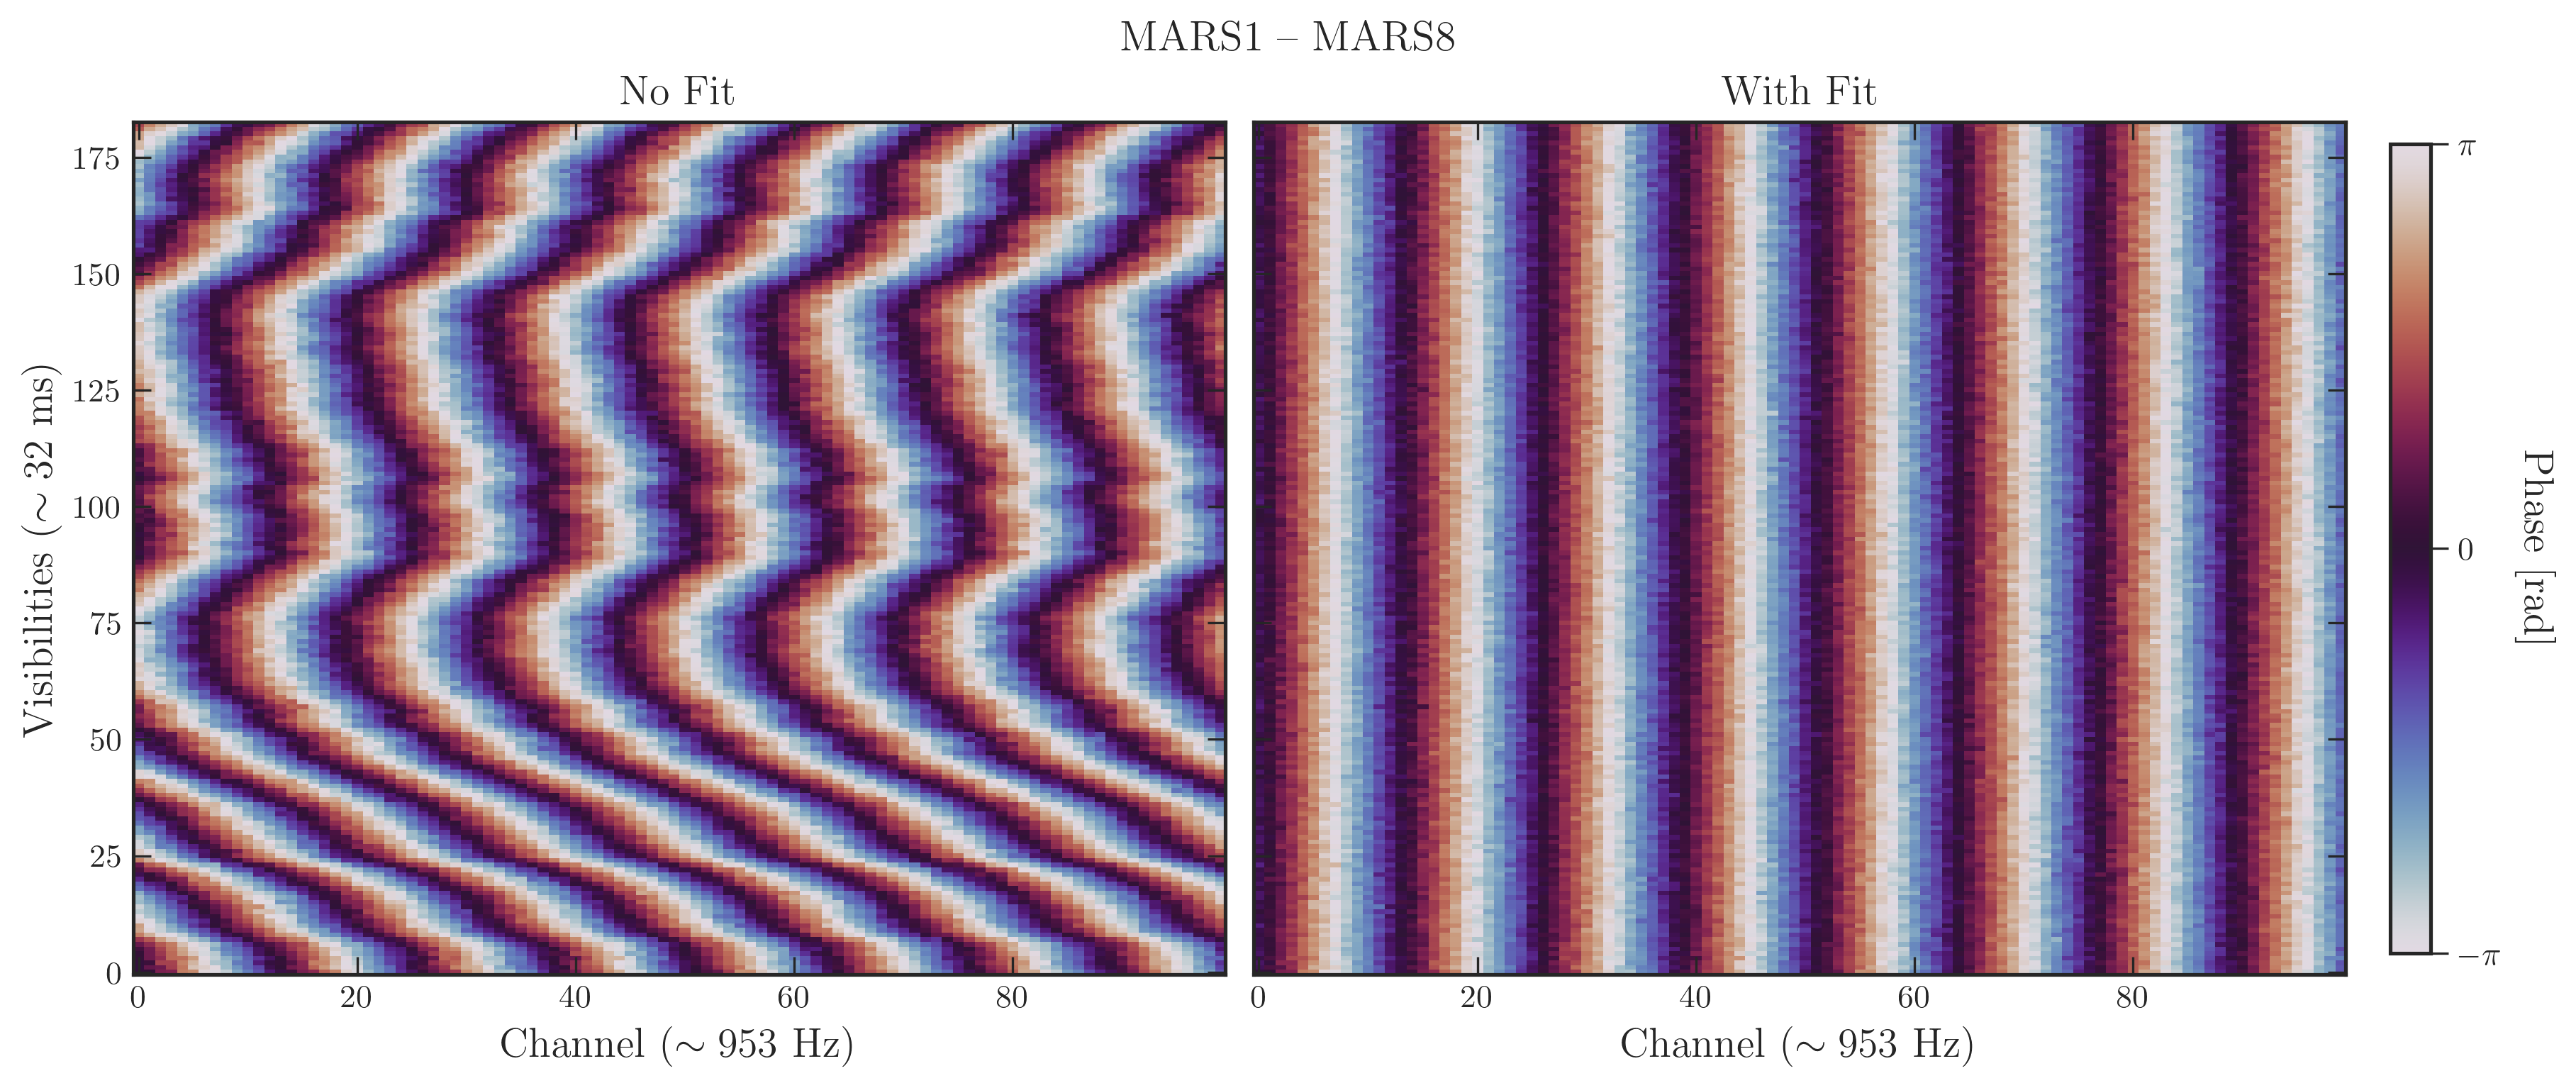

In [65]:

blnum = 0
vmin = -np.pi
vmax = np.pi

fig, ax = plt.subplots(1, 2,figsize=(12, 5),sharey=True,constrained_layout=True)

#left
im = ax[0].imshow(np.angle(vis2[blnum, :, :]),aspect='auto',interpolation='nearest',cmap='twilight',origin='lower',vmin=vmin,vmax=vmax)
ax[0].set_title(r"No Fit")
ax[0].set_ylabel(rf"Visibilities ($\sim {int(acclen * T_SPECTRA * 1e3)}$ ms)")
ax[0].set_xlabel(rf"Channel ($\sim {int(250e6 / (osamp * 4096))}$ Hz)")

#right
ax[1].imshow(np.angle(phased_vis[blnum, :, :]),aspect='auto',interpolation='nearest',cmap='twilight',origin='lower',vmin=vmin,vmax=vmax)
ax[1].set_title(r"With Fit")
ax[1].set_xlabel(rf"Channel ($\sim {int(250e6 / (osamp * 4096))}$ Hz)")
ax[1].tick_params(labelleft=False)

#colorbar
cbar = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.95)
cbar.set_label(r"Phase [rad]", rotation=270, labelpad=18)
cbar.set_ticks([-np.pi, 0, np.pi])
cbar.set_ticklabels([r"$-\pi$", r"$0$", r"$\pi$"])

#tick styling
for a in ax:
    a.tick_params(direction='in', top=True, right=True)
fig.suptitle(r"MARS1 -- MARS8")

plt.savefig("/home/thomasb/albatros_analysis/scripts/orbcomm/paper_plots/phase_alignment.png", bbox_inches="tight")
plt.show()

In [70]:
antmap = ['MARS 2', 'MARS 4', 'MARS 5', 'MARS 6', 'MARS 7', 'MARS 8']

antidx = 0
timeidx = 0
N = 10001
print(data_matrix.shape)
print(tau0)
taus_trial1, taus_trial2 = np.tile(tau0, (N, 1)), np.tile(tau0, (N, 1))
taus_trial1[:, antidx] = np.linspace(-30000, 30000, N) + tau0
taus_trial2[:,antidx] = np.linspace(-20, 20, N) + tau0

cost1, cost2 = np.zeros(N), np.zeros(N)
for i in range(N):
    cost1[i] = np.sum(func(taus_trial1[i], data_matrix[timeidx,:,:].ravel(), freqs_normalized, weights)**2)
    cost2[i] = np.sum(func(taus_trial2[i], data_matrix[timeidx,:,:].ravel(), freqs_normalized, weights)**2)

(1, 100, 1)
-82719.60582149029


Text(0.5, 0.98, 'Antenna MARS 2: Initial Guess $\\tau = -82719.6$ ns')

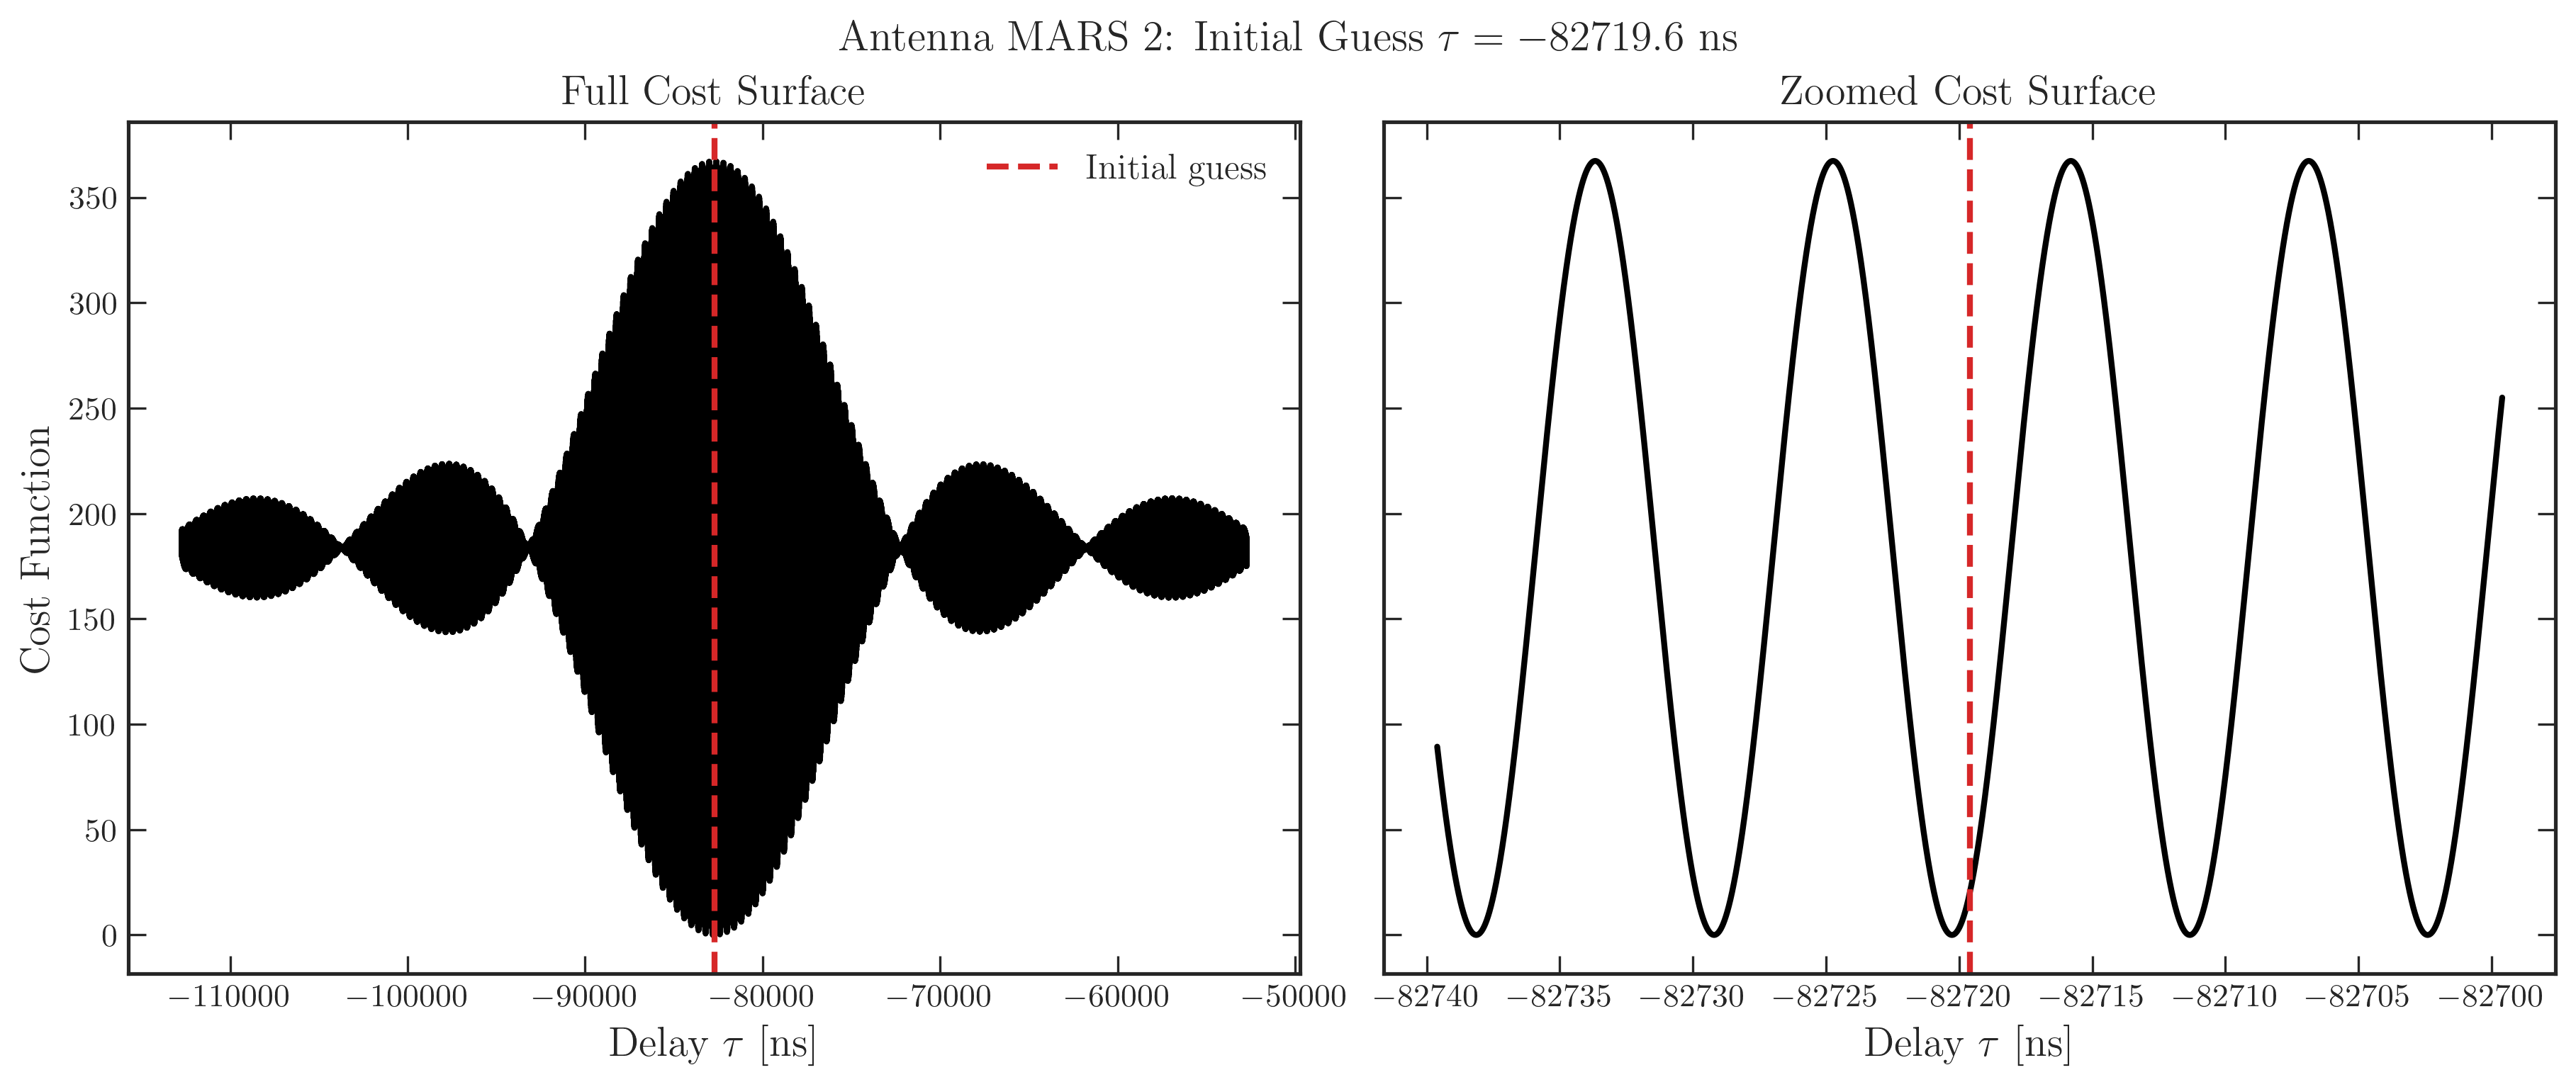

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5),sharey=True,constrained_layout=True)

#left
ax[0].plot(taus_trial1[:, antidx],cost1,lw=2,color='k')
ax[0].axvline(tau0,color='tab:red',ls='--',lw=2,label=r'Initial guess')
ax[0].set_title(r"Full Cost Surface")
ax[0].set_xlabel(r"Delay $\tau$ [ns]")
ax[0].set_ylabel(r"Cost Function")
ax[0].legend(frameon=False)

#right
ax[1].plot(taus_trial2[:, antidx],cost2,lw=2,color='k')
ax[1].axvline(tau0,color='tab:red',ls='--',lw=2)
ax[1].set_title(r"Zoomed Cost Surface")
ax[1].set_xlabel(r"Delay $\tau$ [ns]")

#styling
for a in ax:
    a.tick_params(direction='in',top=True,right=True)
fig.suptitle(rf"Antenna {antmap[antidx]}: Initial Guess "rf"$\tau = {tau0:.1f}$ ns")

In [77]:
print(np.argmin(cost2[4800:5200]))
print(taus_trial2[np.argmin(cost2[4800:5200])+4800])

33
[-82720.27382149]


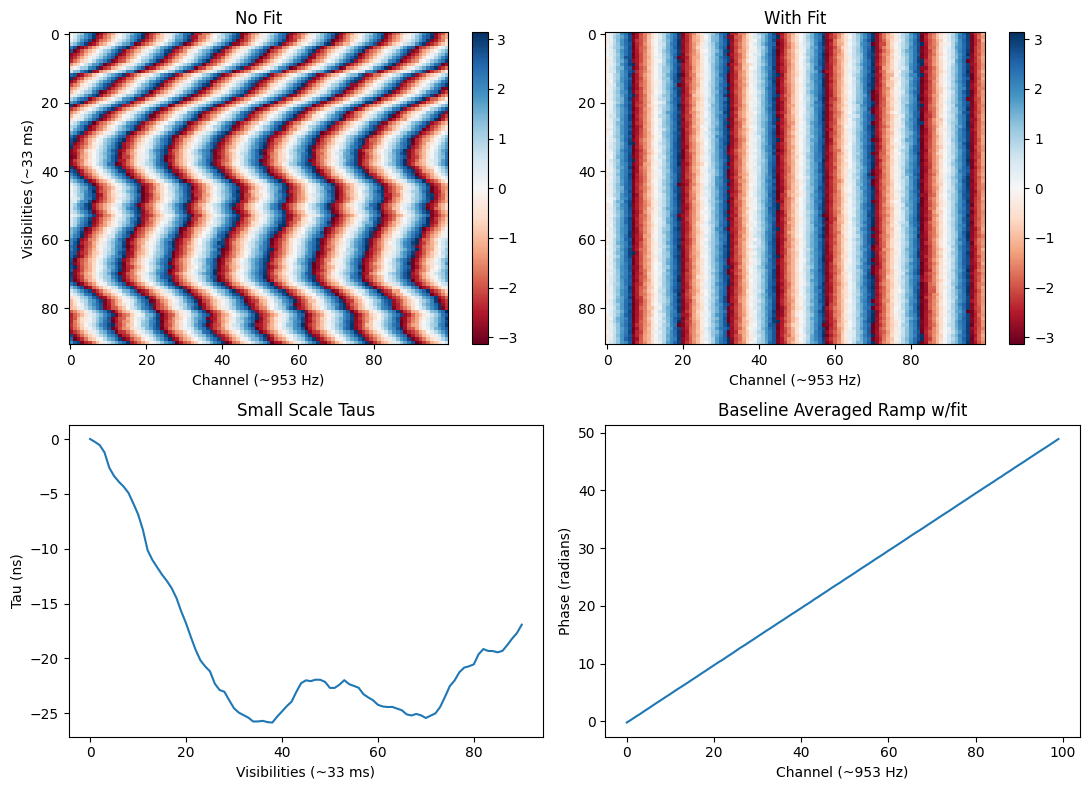

In [ ]:
blnum = 0
fig, ax = plt.subplots(2,2, figsize=(11, 8))
ax = ax.ravel()

img=ax[0].imshow(np.angle(vis2[blnum,:,:]),aspect='auto',interpolation='none',cmap='RdBu')
cbar=plt.colorbar(img,ax=ax[0])
ax[0].set_ylabel(f'Visibilities (~{int(acclen*T_SPECTRA*1e3)} ms)')
ax[0].set_xlabel(f'Channel (~{int(250e6/(osamp*4096))} Hz)')
ax[0].set_title('No Fit')

img=ax[1].imshow(np.angle(phased_vis[blnum,:,:]),aspect='auto',interpolation='none',cmap='RdBu')
cbar=plt.colorbar(img,ax=ax[1])
ax[1].set_title('With Fit')
ax[1].set_xlabel(f'Channel (~{int(250e6/(osamp*4096))} Hz)')


ax[2].plot(taus_small[:,0])
ax[2].set_title('Small Scale Taus')
ax[2].set_xlabel(f'Visibilities (~{int(acclen*T_SPECTRA*1e3)} ms)')
ax[2].set_ylabel('Tau (ns)')

ax[3].plot(np.unwrap(np.angle(avg_multi_vis[:,blnum])))
ax[3].set_title('Baseline Averaged Ramp w/fit')
ax[3].set_xlabel(f'Channel (~{int(250e6/(osamp*4096))} Hz)')
ax[3].set_ylabel('Phase (radians)')

plt.tight_layout()

In [169]:
# with h5py.File('finetiming_dump1.h5', 'a') as f:
#     ds = f.create_dataset(fname_data, data=taus_fitted_all)
#     ds.attrs['starting_specnum'] = pulse_start_spec_cut